In [1]:
using Random
using LinearAlgebra
using Plots
using Statistics
using LaTeXStrings
using Measures

Plots.default(guidefontsize = 20, tickfontsize = 12, legendfontsize = 18)

In [2]:
# Set random seed for reproducibility
Random.seed!(1234)

TaskLocalRNG()

In [3]:
# QkL-SGD for L2-regularized polynomial regression
function qklsgd_poly(x0, D, t, k, q, Gset, Oset; η=0.001, λ=0, iters=100, xstar=zeros(size(x0)))
    n_data = size(D, 1)
    n_features = size(D, 2)
    x = copy(x0)

    G_loss_hist = Float64[]
    O_loss_hist = Float64[]
    indices = Int[]
    O_allowed = Int[]
    error = Float64[]

    for i in 1:iters
        # Predictions and squared-error loss
        yhat = D * x
        f_vals = 0.5 .* (t .- yhat).^2 .+ (λ / n_data) * sum(x[2:end].^2)

        # Compute losses for good/outlier sets
        G_loss = sum(f_vals[Gset])
        O_loss = (Oset != []) ? sum(f_vals[Oset]) : 0.0

        push!(G_loss_hist, G_loss)
        push!(O_loss_hist, O_loss)
        push!(error, norm(x - xstar)^2)

        # Shuffle and quantile selection
        samp = shuffle(1:n_data)[1:k] 
        qval = quantile(f_vals[samp], q)
        B_ind = findall(f_vals[samp] .<= qval)
        B_set = samp[B_ind]  # Map back to original indices

        # Track overlap with Oset
        push!(O_allowed, length(intersect(B_set, Oset)))

        # Pick a random index from B_set
        idx = rand(B_set)
        push!(indices, idx)

        # Gradient for squared loss with L2 regularization (no bias reg)
        di = D[idx, :]
        ti = t[idx]
        pred = dot(x, di)
        grad = (pred - ti) * di + 2 * (λ / n_data) * [0; x[2:end]]

        # SGD update
        x -= η * grad
    end

    return x, G_loss_hist, O_loss_hist, indices, O_allowed, error
end

function mklsgd_poly(x0, D, t, k, Gset, Oset; η=0.001, λ=0, iters=100, xstar=zeros(size(x0)))
    q = 2.0/k
    return qklsgd_poly(x0, D, t, k, q, Gset, Oset, η=η, iters=iters, xstar=xstar)
end

mklsgd_poly (generic function with 1 method)

# No outlier examples with $q=1$

In [4]:
# Generate polynomial regression data (no major outliers)
begin
    n_samples = 200
    x = range(-3, 3, length=n_samples)
    
    degree = 3  # polynomial degree

    # True polynomial coefficients: y = 1 + 0.5x - 0.2x^2 + 0.05x^3 + noise
    coeffs = [1.0, 0.5, -0.2, 0.05]

    # Construct design matrix D (features x samples)
    D = [x.^i for i in 0:degree]  # list of rows [1, x, x^2, x^3]
    D = hcat(D...)  # convert to matrix

    # Generate targets with small Gaussian noise
    noise_std = 0.3
    corruption_std = 10.0
    t = D * coeffs .+ noise_std * randn(n_samples)

    # Use all points as "good" set (no outliers)
    Gset = 1:n_samples
    Oset = []
end

Any[]

In [5]:
# Train model
x0 = zeros(degree + 1)  # initial coefficients
xk, G_loss_hist, O_loss_hist, indices, O_allowed, error = qklsgd_poly(x0, D, t, n_samples, 1.0, Gset, Oset, iters=10000,xstar=coeffs)
mxk, mG_loss_hist, O_loss_hist, indices, O_allowed, error = mklsgd_poly(x0, D, t, n_samples, Gset, Oset, iters=10000,xstar=coeffs)

# Plot loss curve
plot(G_loss_hist, xlabel=L"Iteration $t$", ylabel=L"$F(\mathbf{x}_t)$", label=L"SGD", lw=3, dpi=500,margin=5mm)
plot!(mG_loss_hist, label=L"MkL-SGD", lw=3)
savefig("figs/polyregression_loss_0percoutlier.png")

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_loss_0percoutlier.png"

In [6]:
# Predicted values
y_pred = D * xk

# True noiseless curve for comparison
y_true = D * coeffs

# --- Visualization ---
scatter(x, t, label="Data", color=:gray, alpha=0.5, legend=:bottomright)
plot!(x, y_true, label="True polynomial", color=:black, linewidth=3)
plot!(x, y_pred, label="Fitted polynomial", color=:red, linewidth=2, linestyle=:dash)
xlabel!("x")
ylabel!("y")
savefig("figs/polyregression_viz_0percoutlier.png")

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_viz_0percoutlier.png"

# Outlier example -- $\beta = 0.1$, $q = 0.9$

In [7]:

begin
    β = 0.1
	Oset = rand(1:n_samples, Int(β*n_samples))  # Randomly select Oset indices
    t = D * coeffs .+ noise_std * randn(n_samples)
    t[Oset] .= t[Oset] + corruption_std*randn(Int(β*n_samples))
    Gset = setdiff(1:n_samples, Oset);  # Gset is the complement of Oset
end

181-element Vector{Int64}:
   1
   2
   3
   4
   7
   8
   9
  10
  11
  12
  13
  14
  15
   ⋮
 189
 190
 191
 192
 193
 194
 195
 196
 197
 198
 199
 200

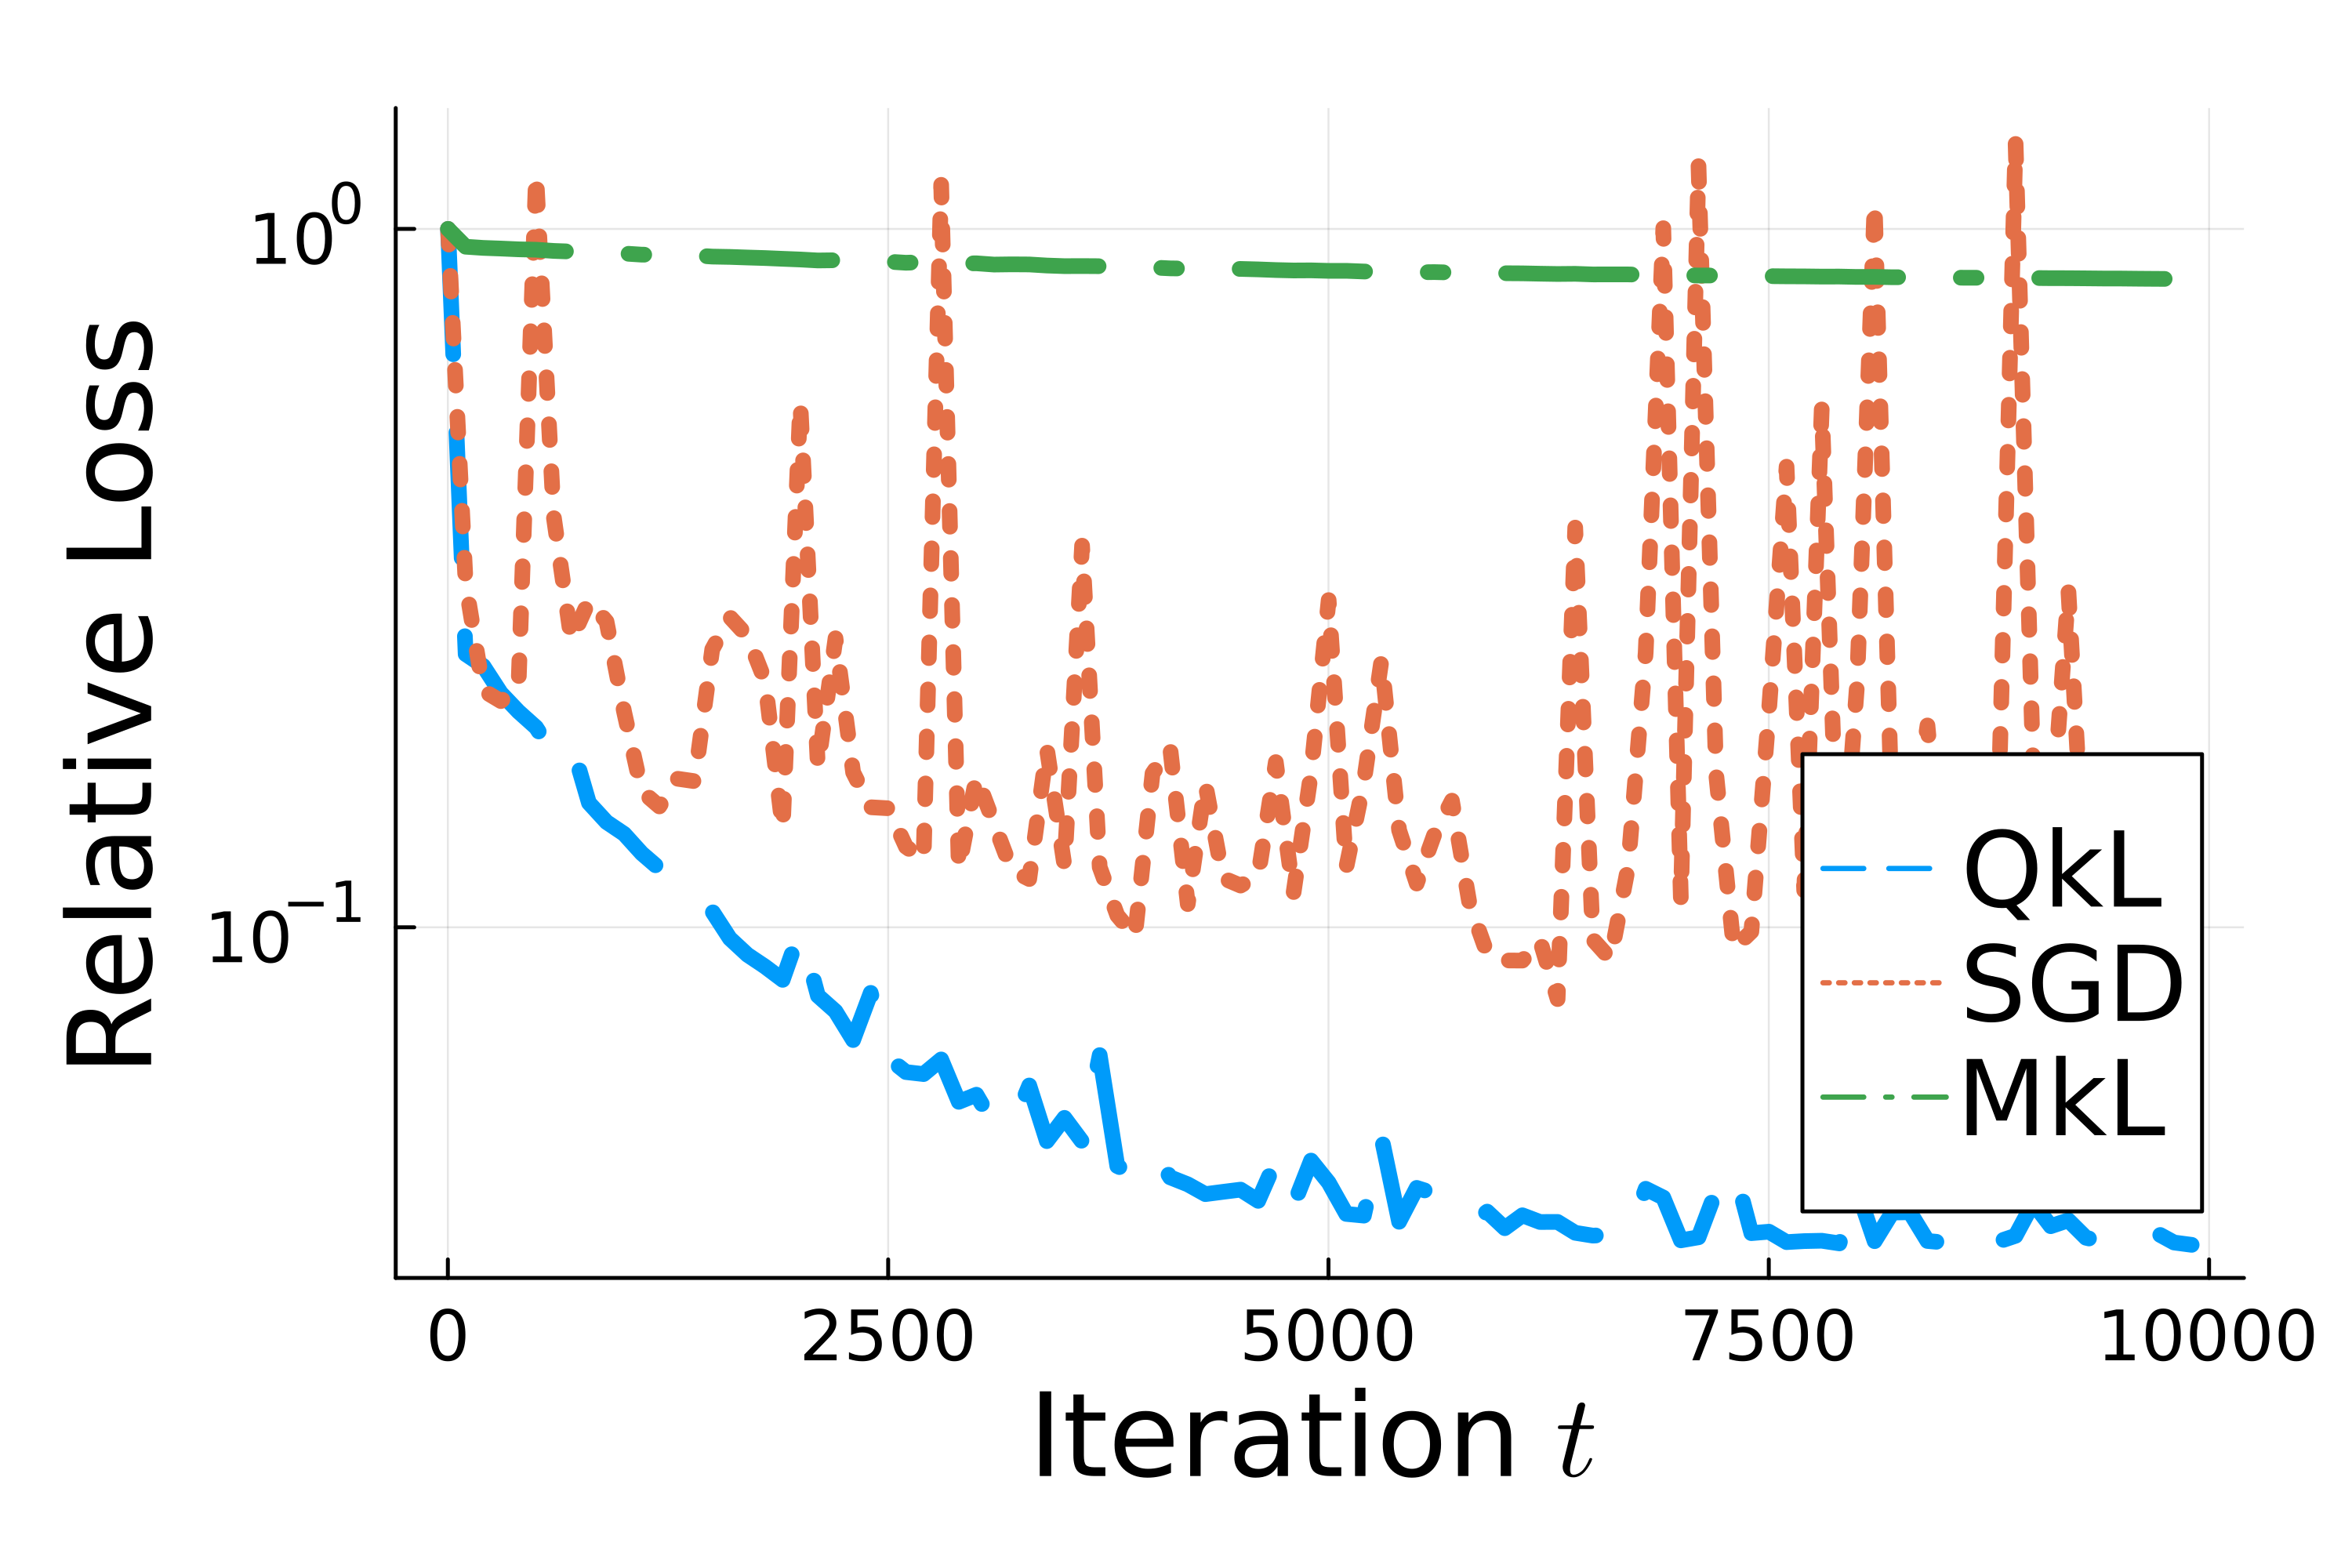

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_loss_10percoutlier.png"

In [8]:
# Train model
x0 = zeros(degree + 1)  # initial coefficients
sgd_xk, G_loss_hist, O_loss_hist, indices, O_allowed, sgd_error = qklsgd_poly(x0, D, t, n_samples, 1.0, Gset, Oset, iters=10000,xstar=coeffs)
qklsgd_xk, qkl_G_loss_hist, O_loss_hist, indices, O_allowed, qklsgd_error = qklsgd_poly(x0, D, t, n_samples, 0.9, Gset, Oset, iters=10000,xstar=coeffs)
mklsgd_xk, mkl_G_loss_hist, O_loss_hist, indices, O_allowed, mklsgd_error = mklsgd_poly(x0, D, t, n_samples, Gset, Oset, iters=10000,xstar=coeffs)

iters = 1:10000

# Plot loss curve
# Main plots (hidden from legend)
p = plot(iters[1:100:end], qkl_G_loss_hist[1:100:end]/qkl_G_loss_hist[1],
     label=nothing, linestyle=:dash, xlabel=L"Iteration $t$",
     ylabel="Relative Loss", lw=4, dpi=500,
     margin=5mm, yscale=:log10,legend=(0.85,0.35))

plot!(iters[1:100:end], G_loss_hist[1:100:end]/G_loss_hist[1],
      label=nothing, linestyle=:dot, lw=4, yscale=:log10)

plot!(iters[1:100:end], mkl_G_loss_hist[1:100:end]/mkl_G_loss_hist[1],
      label=nothing, linestyle=:dashdot, lw=4, yscale=:log10)

# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="QkL", linestyle=:dash, lw=0.6, color=1)
plot!([NaN], [NaN], label="SGD", linestyle=:dot, lw=0.6, color=2)
plot!([NaN], [NaN], label="MkL", linestyle=:dashdot, lw=0.6, color=3)
display(p)
savefig("figs/polyregression_loss_10percoutlier.png")

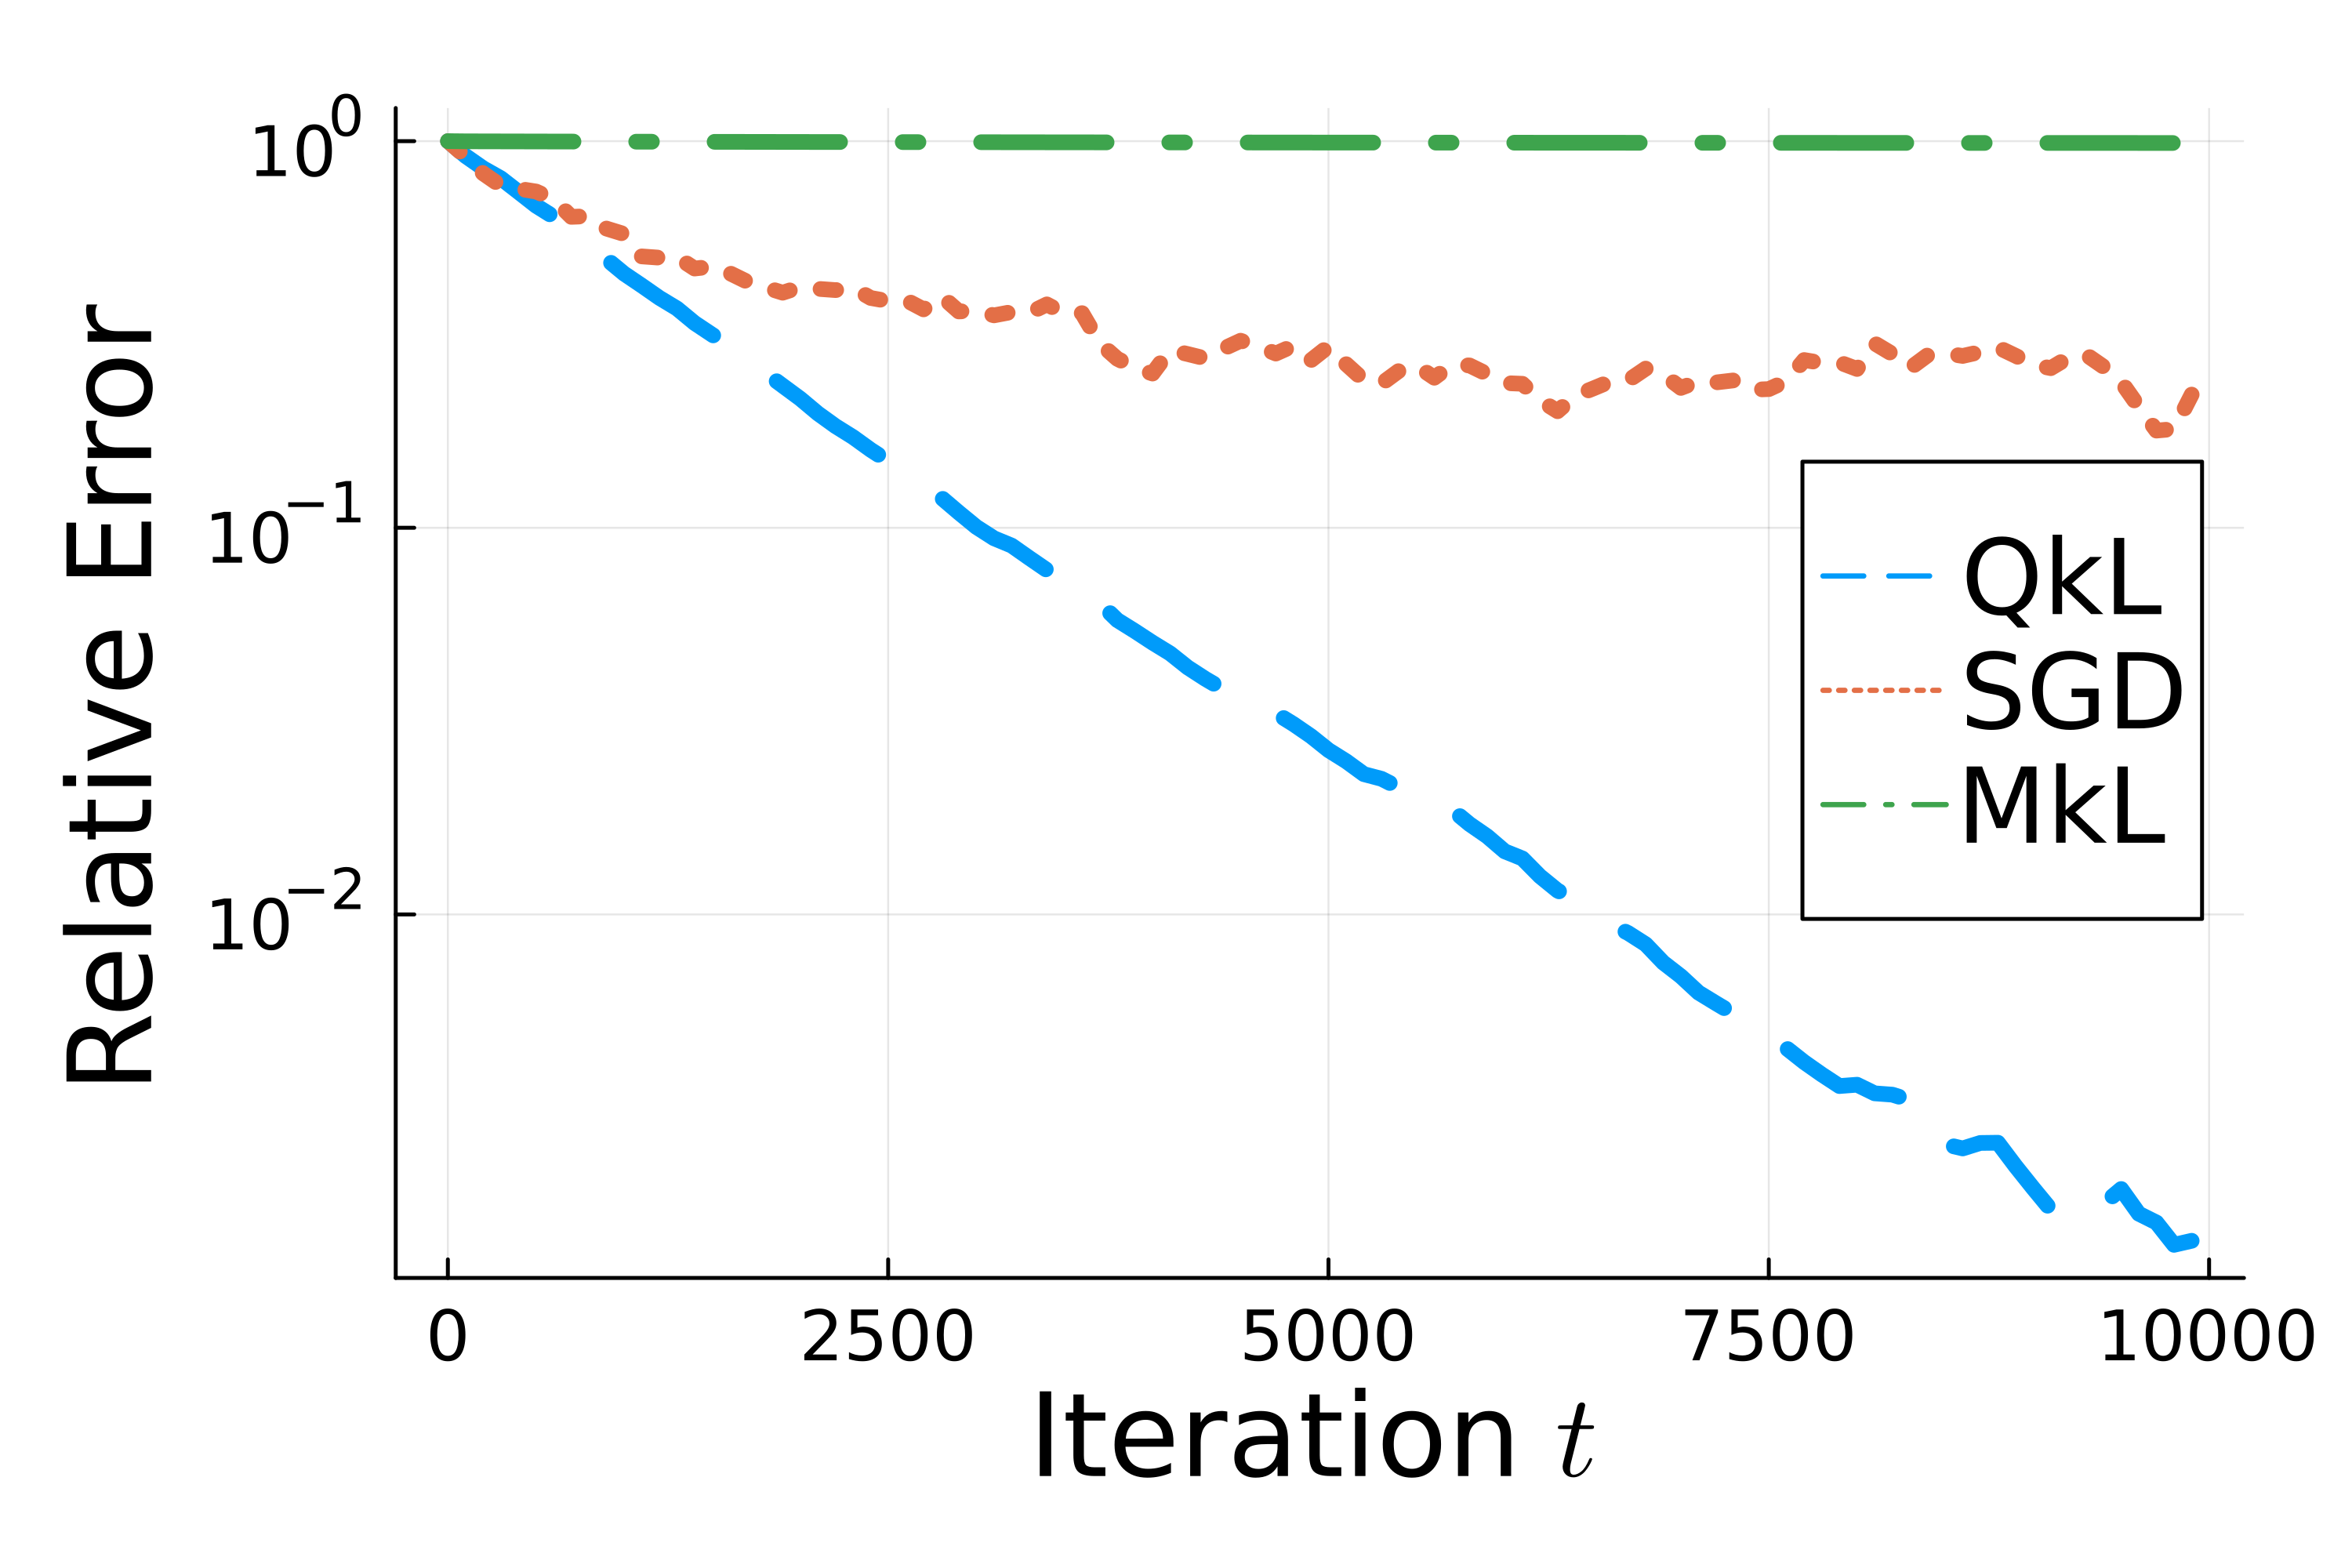

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_error_10percoutlier.png"

In [9]:
iters = 1:10000

# Plot error curve
p = plot(iters[1:100:end],qklsgd_error[1:100:end]/qklsgd_error[1], xlabel=L"Iteration $t$", ylabel="Relative Error", lw=4,yscale=:log10, dpi=500,margin=5mm, linestyle=:dash, label=nothing,legend=(0.85,0.6))
plot!(iters[1:100:end],sgd_error[1:100:end]/sgd_error[1], linestyle=:dot, lw=4,yscale=:log10, label=nothing)
plot!(iters[1:100:end],mklsgd_error[1:100:end]/mklsgd_error[1], linestyle=:dashdot, lw=4,yscale=:log10, label=nothing)

# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="QkL", linestyle=:dash, lw=0.6, color=1)
plot!([NaN], [NaN], label="SGD", linestyle=:dot, lw=0.6, color=2)
plot!([NaN], [NaN], label="MkL", linestyle=:dashdot, lw=0.6, color=3)
display(p)
savefig("figs/polyregression_error_10percoutlier.png")

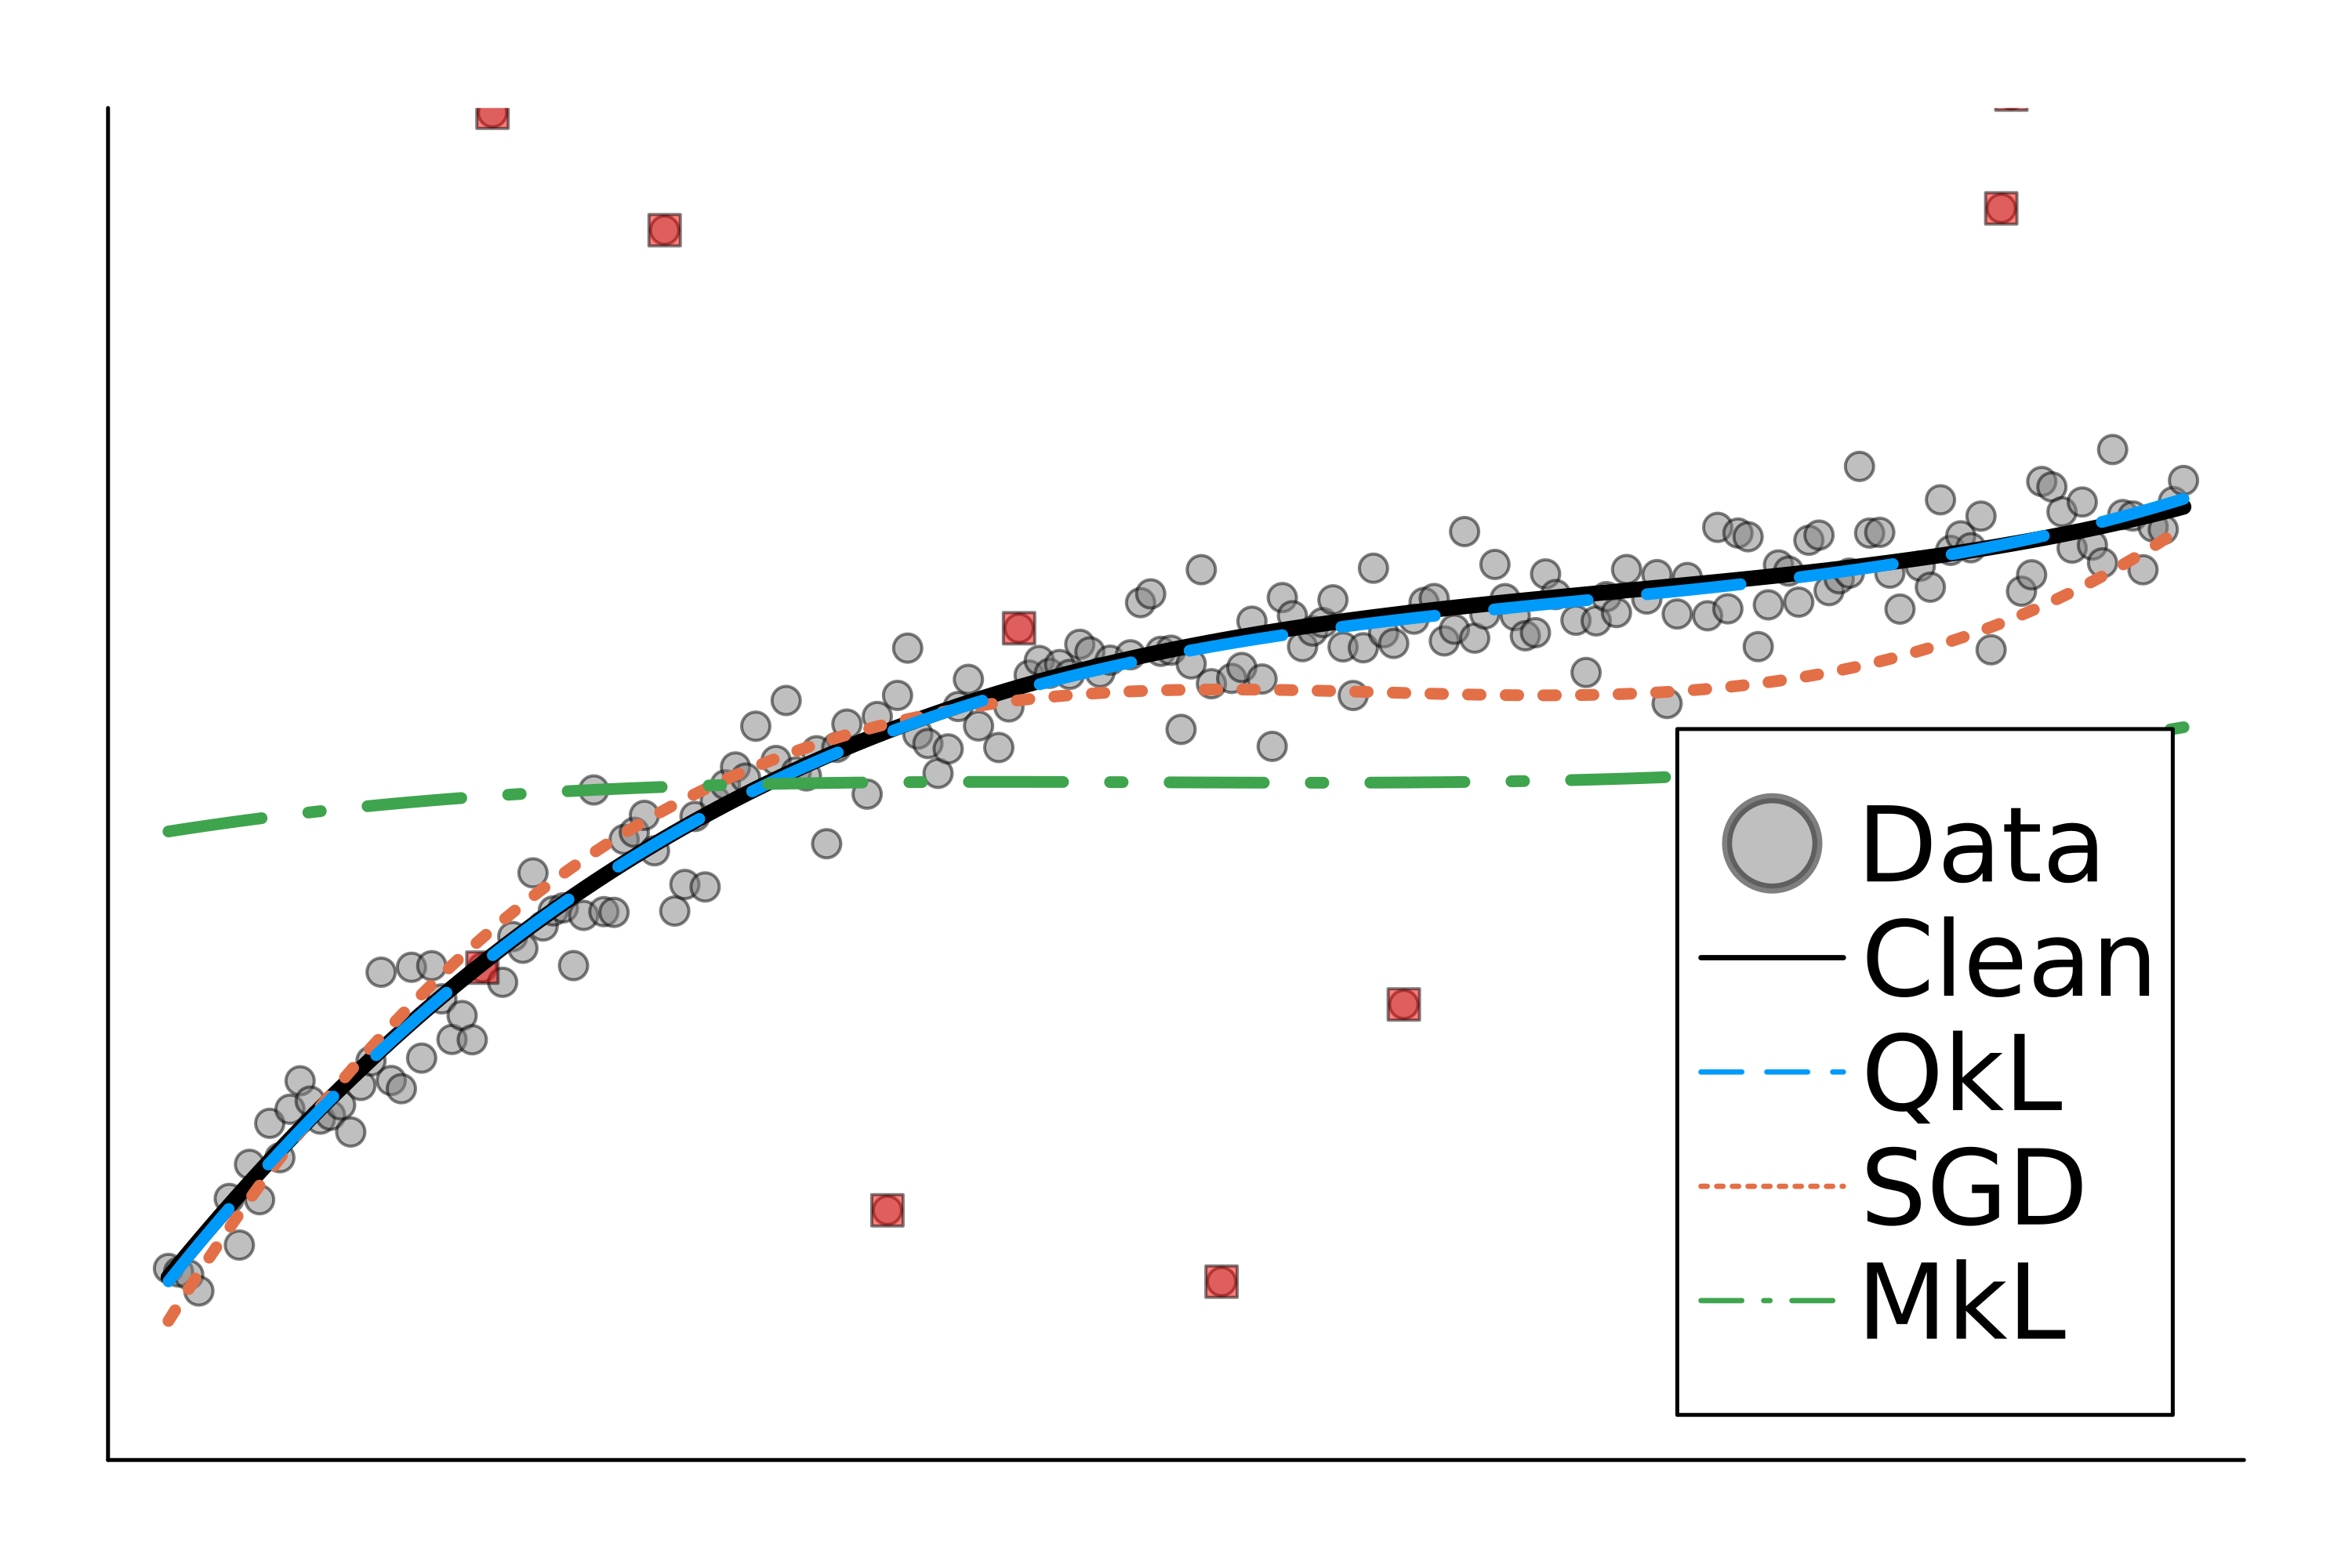

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_viz_10percoutlier.png"

In [10]:
# Predicted values
y_pred_sgd = D * sgd_xk
y_pred_qkl = D * qklsgd_xk
y_pred_mkl = D * mklsgd_xk

# True noiseless curve for comparison
y_true = D * coeffs

# --- Visualization ---
p = scatter(x, t, label="Data", color=:gray, alpha=0.5, legend=:bottomright,ylim=(-5, 5),ticks=false,dpi=500,margin=5mm)
scatter!(x[Oset], t[Oset], label=nothing, color=:red, alpha=0.5, marker=:square,ylim=(-5, 5))
plot!(x, y_true, label=nothing, color=:black, linestyle=:solid, linewidth=4,ylim=(-5, 5))
plot!(x, y_pred_sgd, label=nothing, color=2, linewidth=3, linestyle=:dot,ylim=(-5, 5))
plot!(x, y_pred_qkl, label=nothing, color=1, linewidth=3, linestyle=:dash,ylim=(-5, 5))
plot!(x, y_pred_mkl, label=nothing, color=3, linewidth=3, linestyle=:dashdot,ylim=(-5, 5))

# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="Clean", linestyle=:solid, lw=0.6, color=:black)
plot!([NaN], [NaN], label="QkL", linestyle=:dash, lw=0.6, color=1)
plot!([NaN], [NaN], label="SGD", linestyle=:dot, lw=0.6, color=2)
plot!([NaN], [NaN], label="MkL", linestyle=:dashdot, lw=0.6, color=3)

#xlabel!("x")
#ylabel!("y")
ylim=(-5, 5)
display(p)
savefig("figs/polyregression_viz_10percoutlier.png")

# Outlier example -- $\beta = 0.05$, $q = 0.95$

In [11]:

begin
    β = 0.05
	Oset = rand(1:n_samples, Int(β*n_samples))  # Randomly select Oset indices
    t = D * coeffs .+ noise_std * randn(n_samples)
    t[Oset] .= t[Oset] + corruption_std*randn(Int(β*n_samples))
    Gset = setdiff(1:n_samples, Oset);  # Gset is the complement of Oset
end

190-element Vector{Int64}:
   1
   2
   3
   4
   5
   6
   7
   8
   9
  10
  11
  12
  13
   ⋮
 187
 188
 190
 191
 192
 193
 194
 195
 197
 198
 199
 200

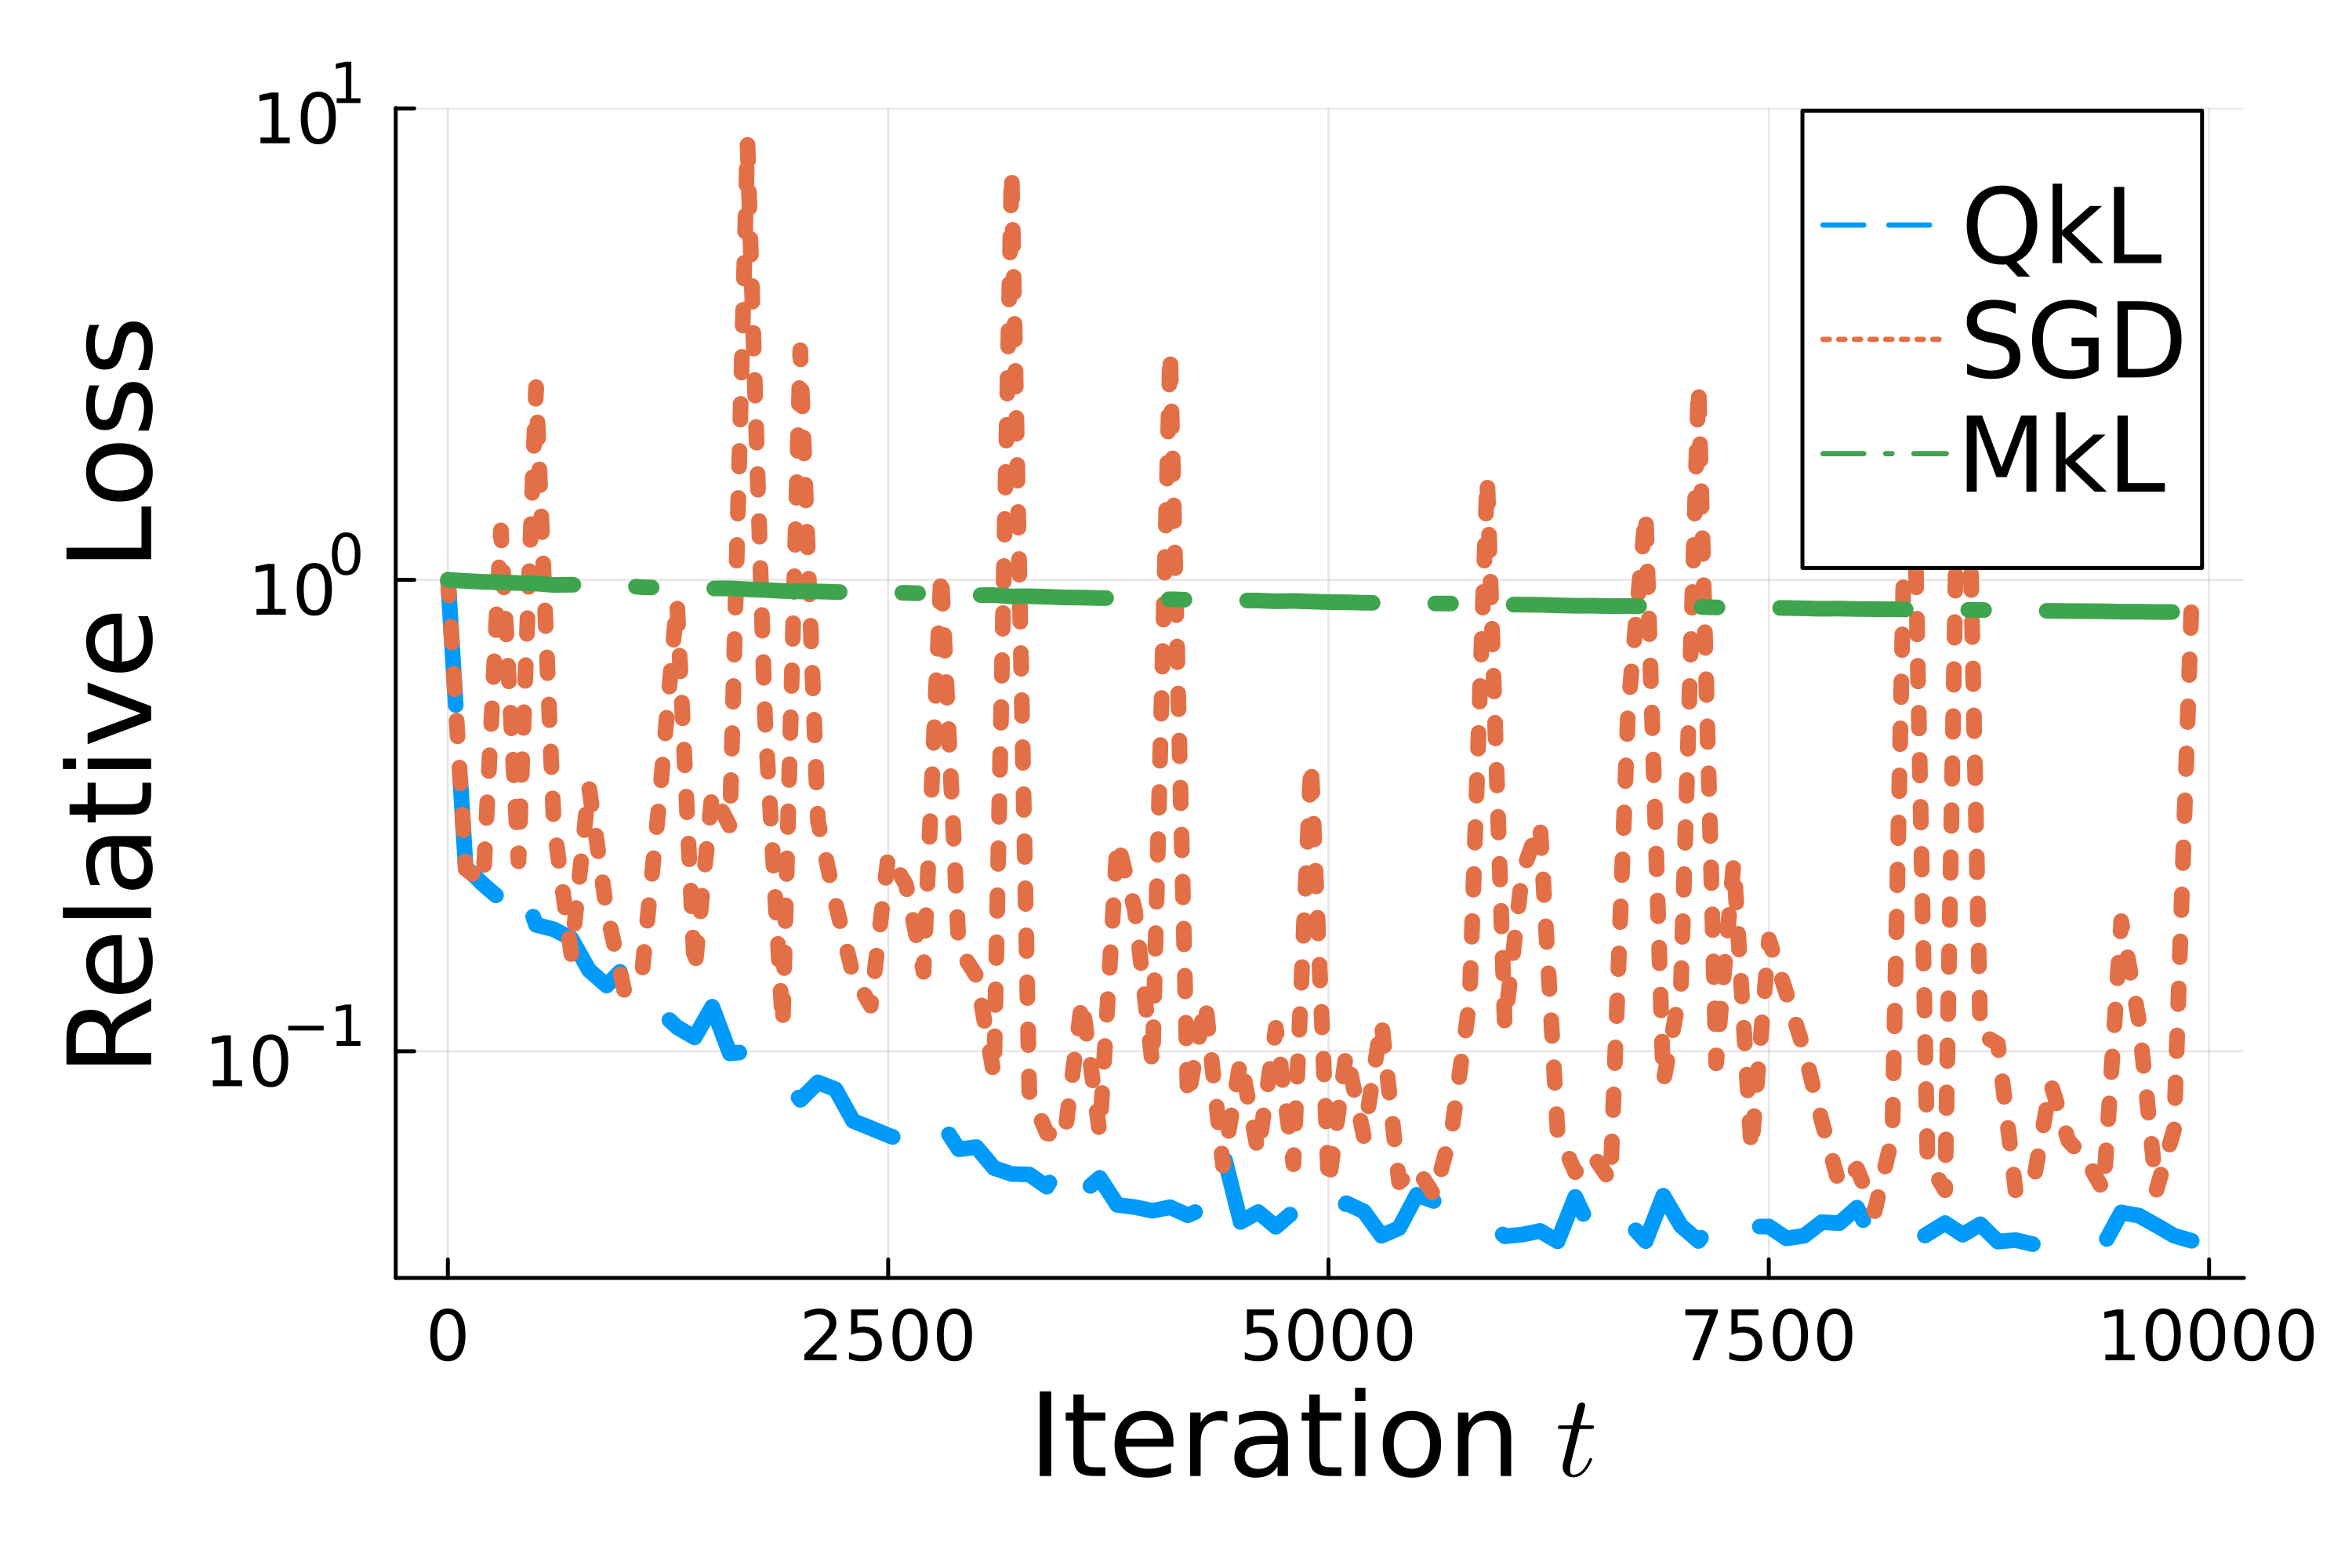

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_loss_5percoutlier.png"

In [12]:
# Train model
x0 = zeros(degree + 1)  # initial coefficients
sgd_xk, G_loss_hist, O_loss_hist, indices, O_allowed, sgd_error = qklsgd_poly(x0, D, t, n_samples, 1.0, Gset, Oset, iters=10000,xstar=coeffs)
qklsgd_xk, qkl_G_loss_hist, O_loss_hist, indices, O_allowed, qklsgd_error = qklsgd_poly(x0, D, t, n_samples, 0.95, Gset, Oset, iters=10000,xstar=coeffs)
mklsgd_xk, mkl_G_loss_hist, O_loss_hist, indices, O_allowed, mklsgd_error = mklsgd_poly(x0, D, t, n_samples, Gset, Oset, iters=10000,xstar=coeffs)

iters = 1:10000

# Plot loss curve
# Main plots (hidden from legend)
p = plot(iters[1:100:end], qkl_G_loss_hist[1:100:end]/qkl_G_loss_hist[1],
     label=nothing, linestyle=:dash, xlabel=L"Iteration $t$",
     ylabel="Relative Loss", lw=4, dpi=500,
     margin=5mm, yscale=:log10,legend=(0.85,0.9))

plot!(iters[1:100:end], G_loss_hist[1:100:end]/G_loss_hist[1],
      label=nothing, linestyle=:dot, lw=4, yscale=:log10)

plot!(iters[1:100:end], mkl_G_loss_hist[1:100:end]/mkl_G_loss_hist[1],
      label=nothing, linestyle=:dashdot, lw=4, yscale=:log10)

# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="QkL", linestyle=:dash, lw=0.6, color=1)
plot!([NaN], [NaN], label="SGD", linestyle=:dot, lw=0.6, color=2)
plot!([NaN], [NaN], label="MkL", linestyle=:dashdot, lw=0.6, color=3)
display(p)
savefig("figs/polyregression_loss_5percoutlier.png")

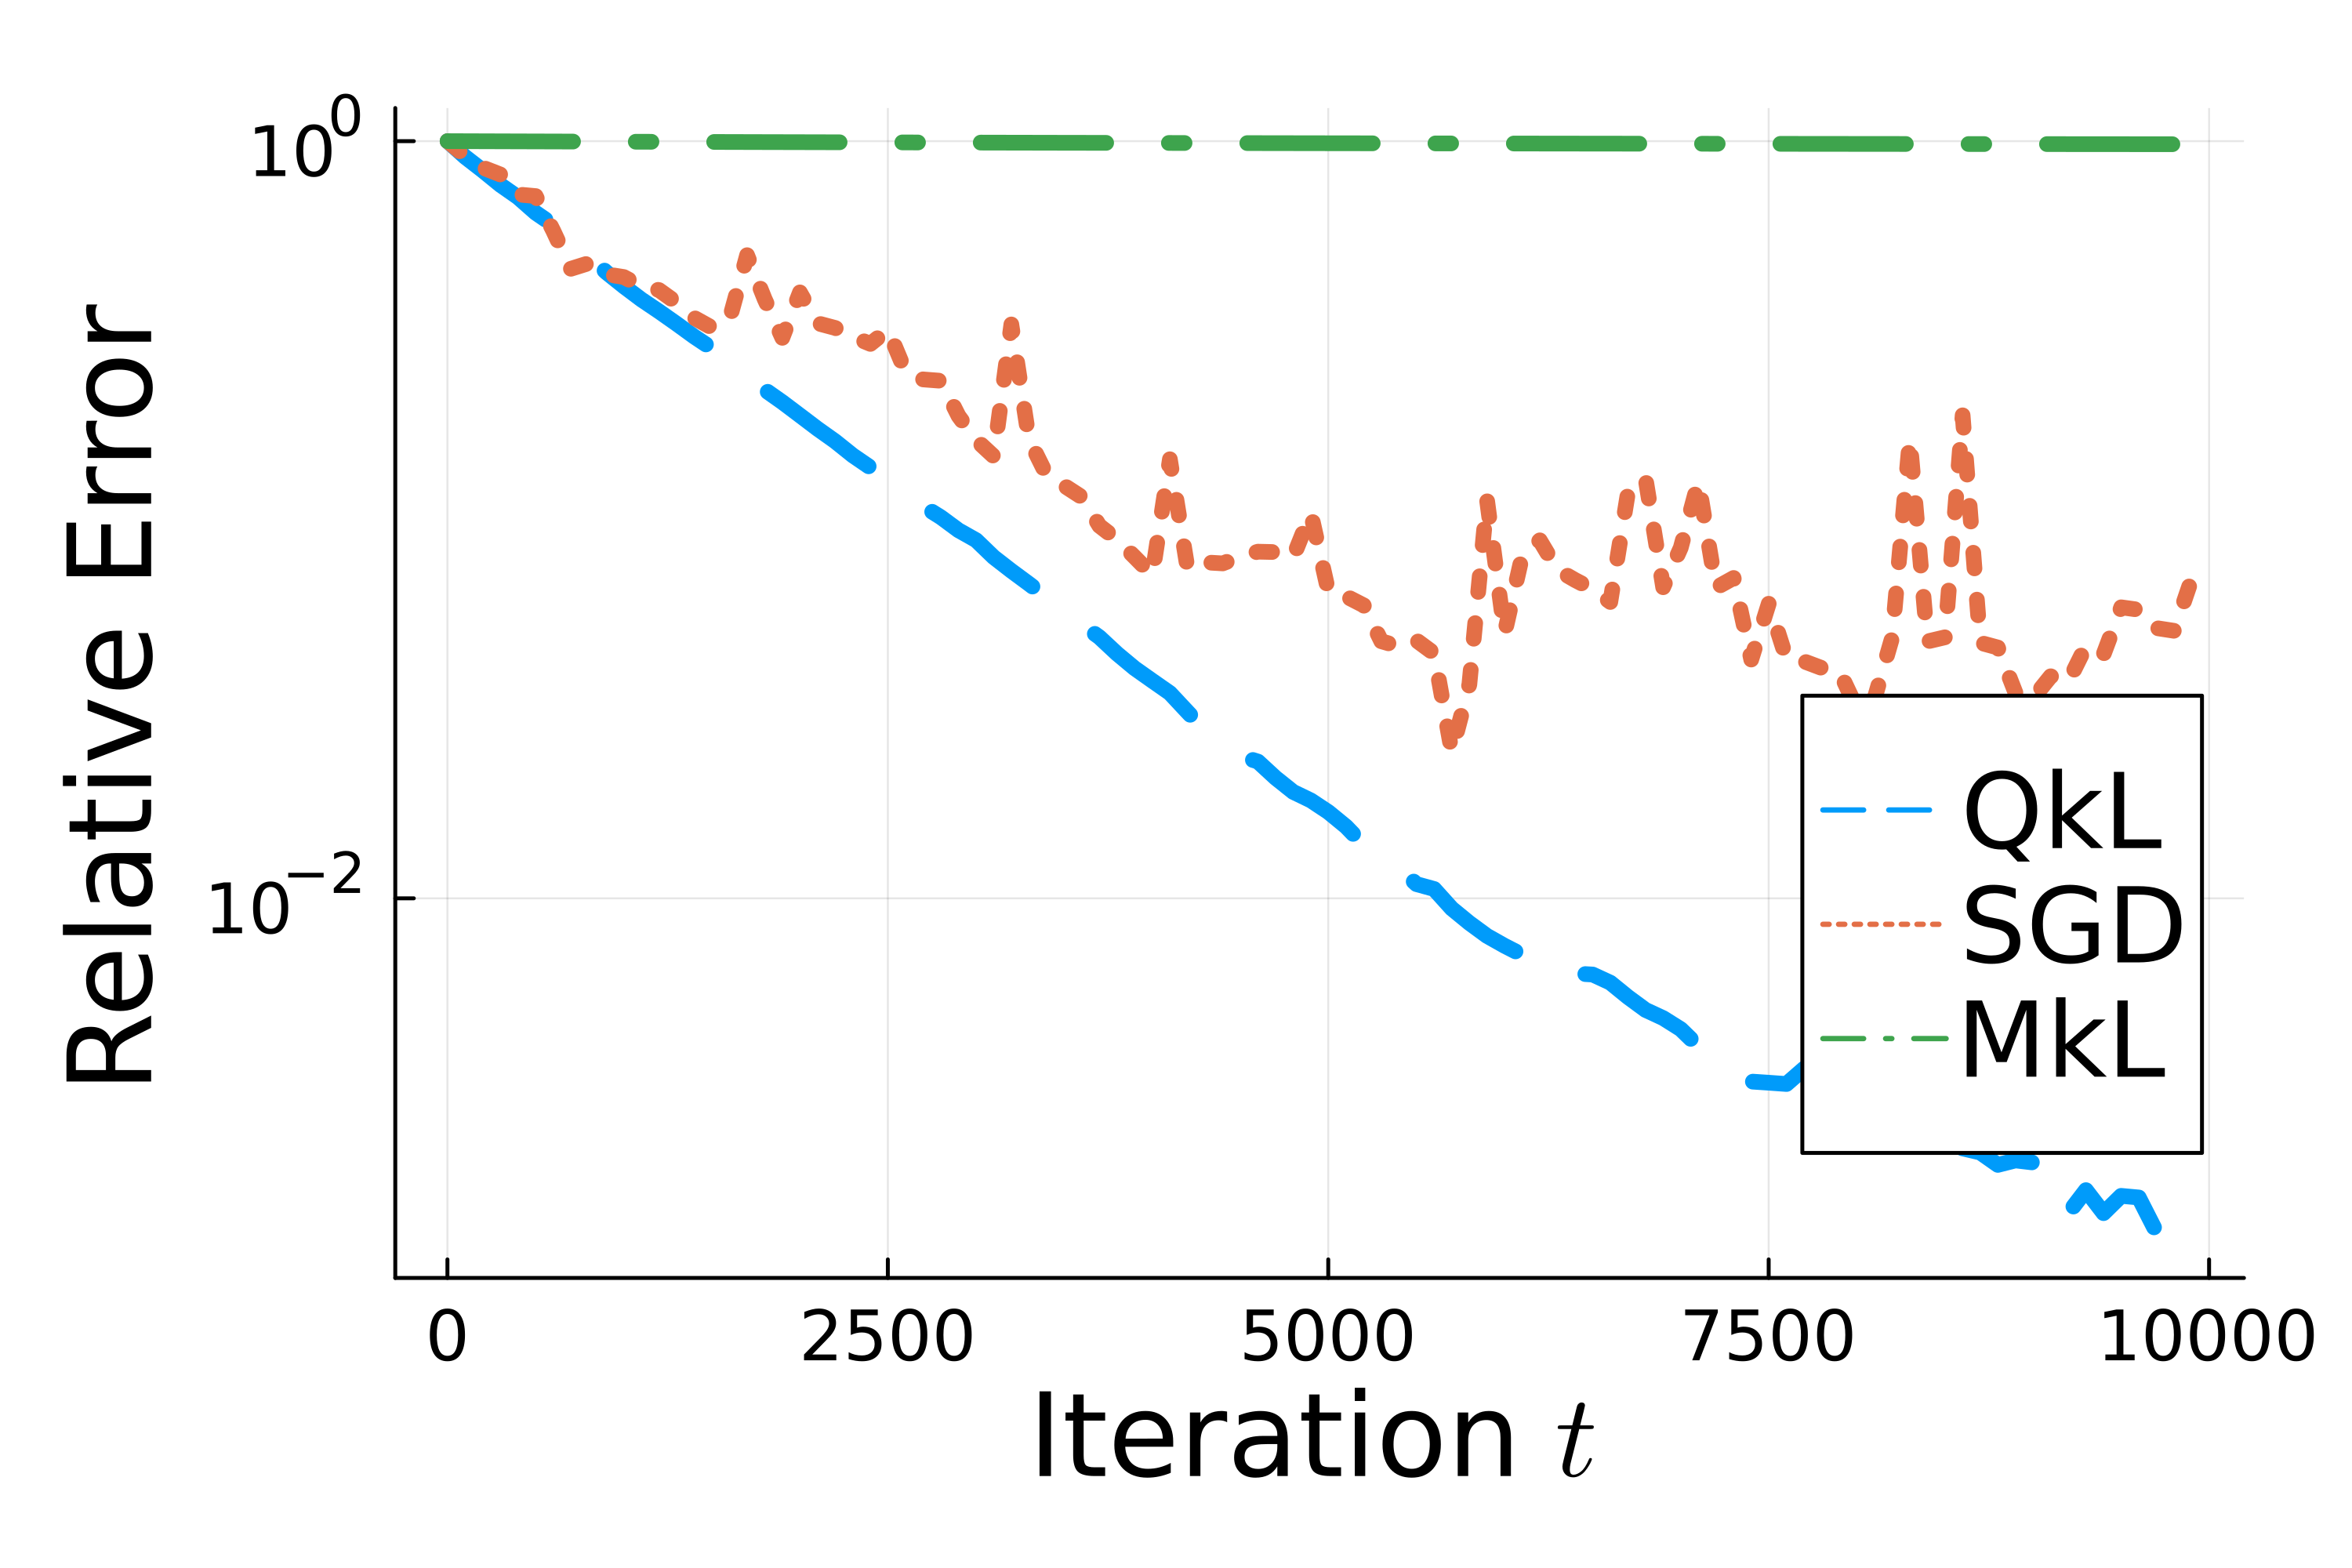

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_error_5percoutlier.png"

In [13]:
iters = 1:10000

# Plot error curve
p = plot(iters[1:100:end],qklsgd_error[1:100:end]/qklsgd_error[1], xlabel=L"Iteration $t$", ylabel="Relative Error", lw=4,yscale=:log10, dpi=500,margin=5mm, linestyle=:dash, label=nothing,legend=(0.85,0.4))
plot!(iters[1:100:end],sgd_error[1:100:end]/sgd_error[1], linestyle=:dot, lw=4,yscale=:log10, label=nothing)
plot!(iters[1:100:end],mklsgd_error[1:100:end]/mklsgd_error[1], linestyle=:dashdot, lw=4,yscale=:log10, label=nothing)

# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="QkL", linestyle=:dash, lw=0.6, color=1)
plot!([NaN], [NaN], label="SGD", linestyle=:dot, lw=0.6, color=2)
plot!([NaN], [NaN], label="MkL", linestyle=:dashdot, lw=0.6, color=3)
display(p)
savefig("figs/polyregression_error_5percoutlier.png")

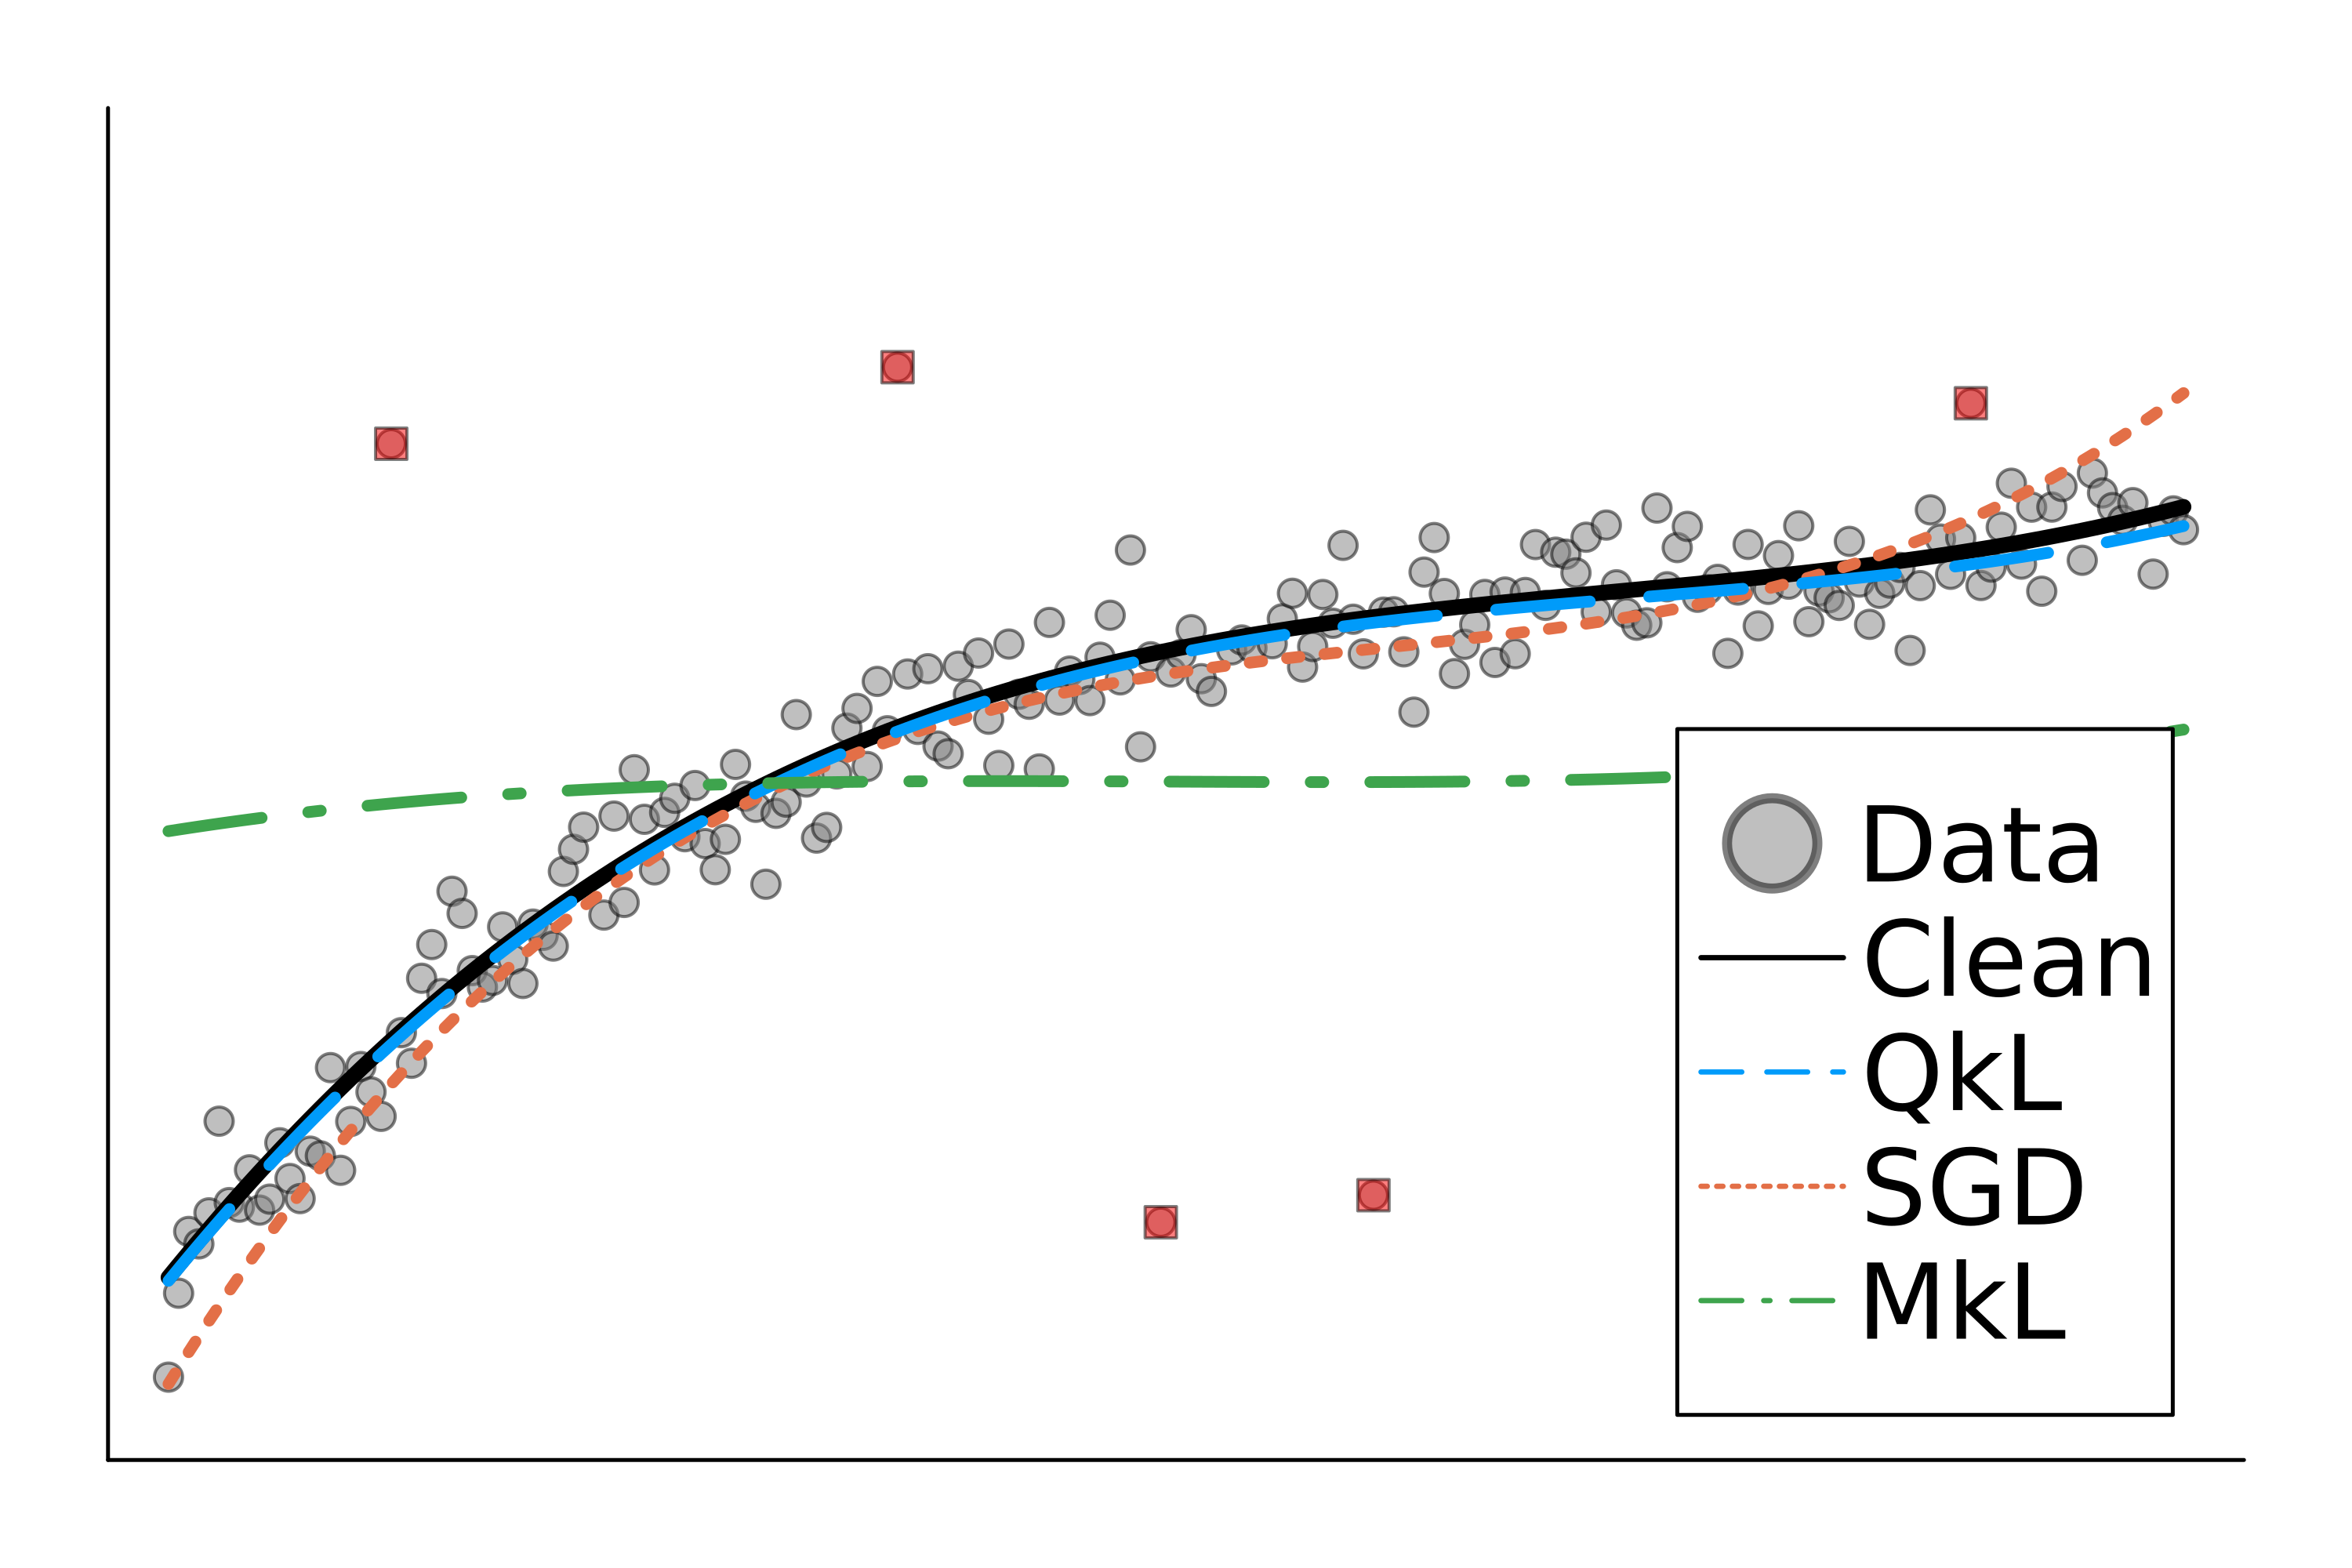

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_viz_5percoutlier.png"

In [14]:
# Predicted values
y_pred_sgd = D * sgd_xk
y_pred_qkl = D * qklsgd_xk
y_pred_mkl = D * mklsgd_xk

# True noiseless curve for comparison
y_true = D * coeffs

# --- Visualization ---
p = scatter(x, t, label="Data", color=:gray, alpha=0.5, legend=:bottomright,ylim=(-5, 5),ticks=false,dpi=500,margin=5mm)
scatter!(x[Oset], t[Oset], label=nothing, color=:red, alpha=0.5, marker=:square,ylim=(-5, 5))
plot!(x, y_true, label=nothing, color=:black, linestyle=:solid, linewidth=4,ylim=(-5, 5))
plot!(x, y_pred_sgd, label=nothing, color=2, linewidth=3, linestyle=:dot,ylim=(-5, 5))
plot!(x, y_pred_qkl, label=nothing, color=1, linewidth=3, linestyle=:dash,ylim=(-5, 5))
plot!(x, y_pred_mkl, label=nothing, color=3, linewidth=3, linestyle=:dashdot,ylim=(-5, 5))

# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="Clean", linestyle=:solid, lw=0.6, color=:black)
plot!([NaN], [NaN], label="QkL", linestyle=:dash, lw=0.6, color=1)
plot!([NaN], [NaN], label="SGD", linestyle=:dot, lw=0.6, color=2)
plot!([NaN], [NaN], label="MkL", linestyle=:dashdot, lw=0.6, color=3)

#xlabel!("x")
#ylabel!("y")
ylim=(-5, 5)
display(p)
savefig("figs/polyregression_viz_5percoutlier.png")

# Small sample size

In [15]:
# Generate linearly separable 2D data with $\beta = 0.05$ fraction mislabelled
begin
    β = 0.05
	Oset = rand(1:n_samples, Int(β*n_samples))  # Randomly select Oset indices
    t = D * coeffs .+ noise_std * randn(n_samples)
    t[Oset] .= t[Oset] + corruption_std*randn(Int(β*n_samples))
    Gset = setdiff(1:n_samples, Oset);  # Gset is the complement of Oset
end

190-element Vector{Int64}:
   1
   2
   3
   4
   5
   6
   7
   8
   9
  10
  11
  12
  13
   ⋮
 189
 190
 191
 192
 193
 194
 195
 196
 197
 198
 199
 200

In [16]:
alpha = 0.9
# Train model with QkL-SGD
qklsgd_x, qkl_G_loss_hist9, O_loss_hist, indices, O_allowed, qklsgd_error9 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

# Train model with MkL-SGD
mklsgd_x, mkl_G_loss_hist9, O_loss_hist, indices, O_allowed, mklsgd_error9 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

alpha = 0.5
# Train model with QkL-SGD
qklsgd_x, qkl_G_loss_hist5, O_loss_hist, indices, O_allowed, qklsgd_error5 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

# Train model with MkL-SGD
mklsgd_x, mkl_G_loss_hist5, O_loss_hist, indices, O_allowed, mklsgd_error5 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

alpha = 0.1
# Train model with QkL-SGD
qklsgd_x, qkl_G_loss_hist1, O_loss_hist, indices, O_allowed, qklsgd_error1 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

# Train model with MkL-SGD
mklsgd_x, mkl_G_loss_hist1, O_loss_hist, indices, O_allowed, mklsgd_error1 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

([0.09782747543144873, -0.02601776641228885, -0.03745920462546599, 0.11513684318944149], [229.92624515046833, 228.76019811684444, 229.89338051751088, 231.26149378289932, 229.92341512372445, 233.62585460890202, 231.3670499184794, 228.1401696389145, 228.2134213870708, 221.4390658839706  …  59.49642697794353, 59.549500841964104, 58.925614498847374, 59.09067356924554, 59.53366780349955, 59.37833265215835, 59.16309598594721, 59.17152286651359, 59.3654107917187, 59.63141027344088], [164.0061618511119, 164.09353179540616, 164.01777863237837, 163.90235744039074, 163.98846679675864, 163.71999757775183, 163.84414096895773, 164.01555940344502, 164.01117275843396, 164.41832503751306  …  175.0090323991863, 174.96580428776707, 175.13125762276556, 175.00114189968207, 174.88314475306396, 174.99785770073427, 175.0448370442564, 175.0345540780471, 174.98619030872197, 174.91811049050133], [63, 57, 68, 55, 62, 43, 38, 49, 48, 76  …  53, 191, 40, 195, 45, 173, 66, 185, 195, 44], [0, 0, 0, 0, 0, 0, 0, 0, 0, 

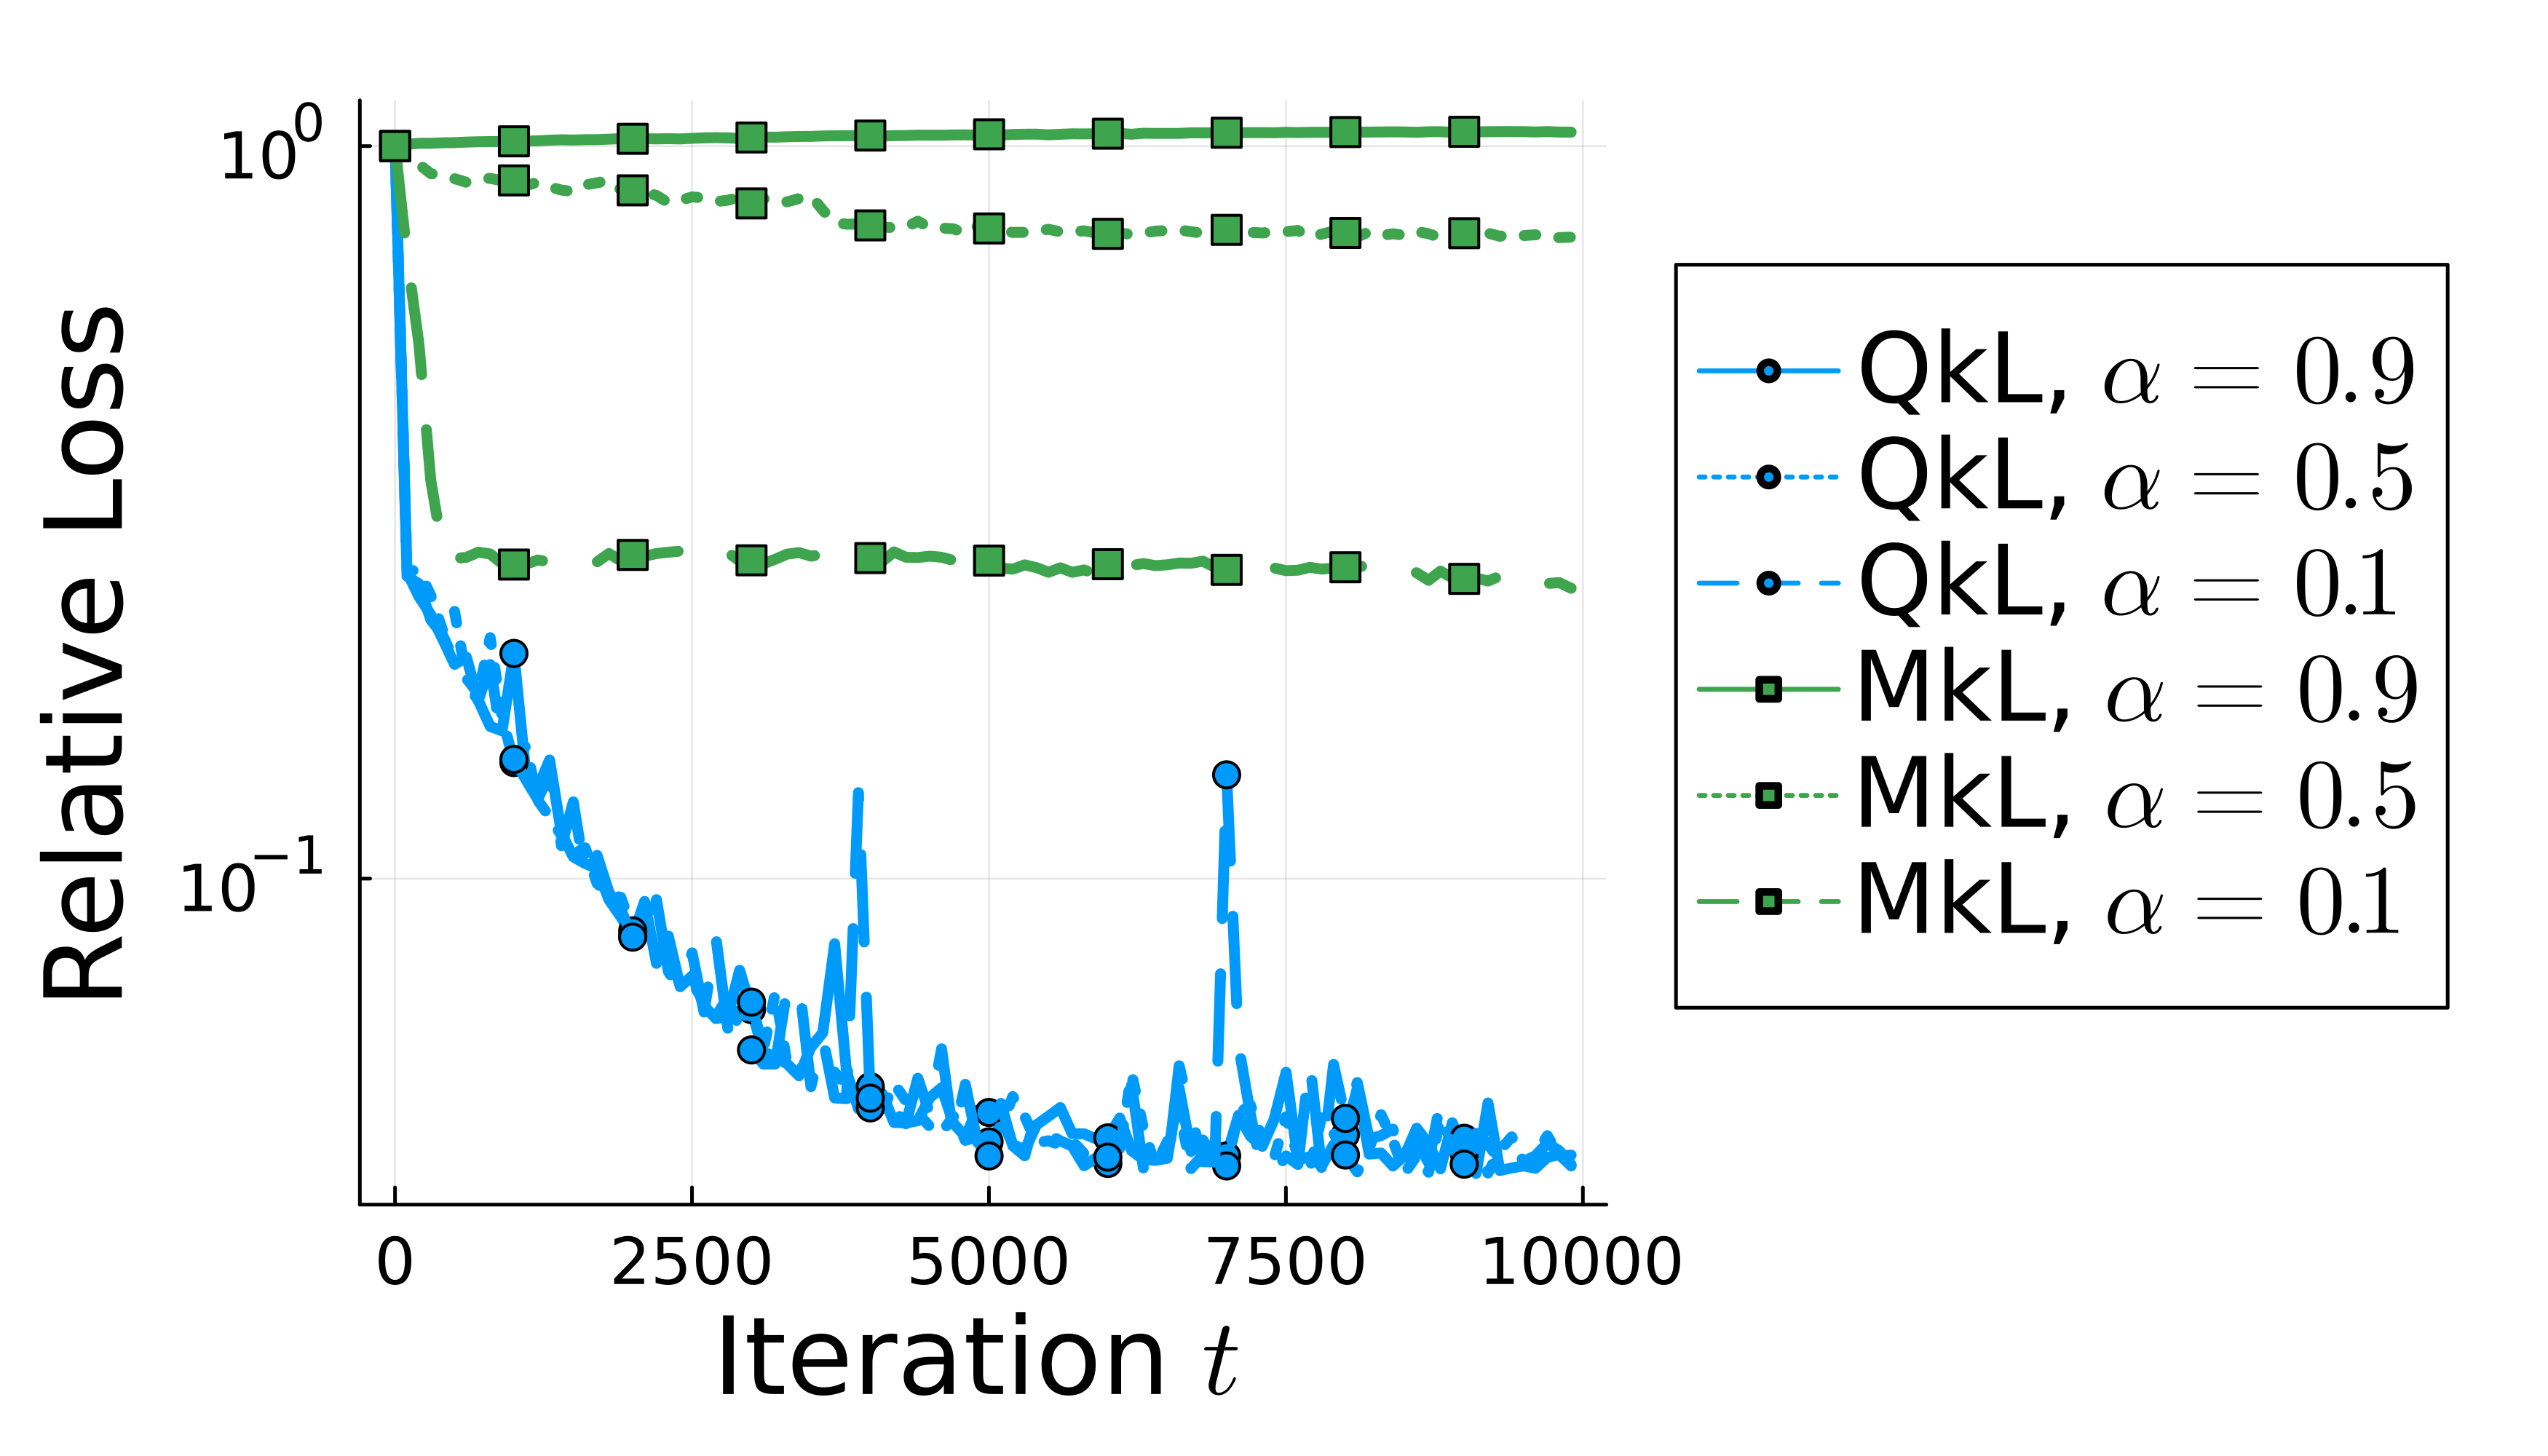

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_loss_varyalpha_5percoutlier.png"

In [17]:
iters = 1:10000

# Plot loss curve
p = plot(iters[1:100:end],qkl_G_loss_hist9[1:100:end]/qkl_G_loss_hist9[1], label=nothing, xlabel=L"Iteration $t$", ylabel="Relative Loss", lw=3, dpi=500,margin=5mm,yscale=:log10,color=1,legend=:outerright,size = (700, 400))
scatter!(iters[1:1000:end],qkl_G_loss_hist9[1:1000:end]/qkl_G_loss_hist9[1], label=nothing, lw=3,yscale=:log10,color=1)
plot!(iters[1:100:end],qkl_G_loss_hist5[1:100:end]/qkl_G_loss_hist5[1], label=nothing, lw=3,yscale=:log10,color=1,linestyle=:dot)
scatter!(iters[1:1000:end],qkl_G_loss_hist5[1:1000:end]/qkl_G_loss_hist5[1], label=nothing, lw=3,yscale=:log10,color=1)
plot!(iters[1:100:end],qkl_G_loss_hist1[1:100:end]/qkl_G_loss_hist1[1], label=nothing, lw=3,yscale=:log10,color=1,linestyle=:dash)
scatter!(iters[1:1000:end],qkl_G_loss_hist1[1:1000:end]/qkl_G_loss_hist1[1], label=nothing, lw=3,yscale=:log10,color=1)
plot!(iters[1:100:end],mkl_G_loss_hist9[1:100:end]/mkl_G_loss_hist9[1], label=nothing, lw=3,yscale=:log10,color=3)
scatter!(iters[1:1000:end],mkl_G_loss_hist9[1:1000:end]/mkl_G_loss_hist9[1], label=nothing, lw=3,yscale=:log10,color=3,marker=:square)
plot!(iters[1:100:end],mkl_G_loss_hist5[1:100:end]/mkl_G_loss_hist5[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dot)
scatter!(iters[1:1000:end],mkl_G_loss_hist5[1:1000:end]/mkl_G_loss_hist5[1], label=nothing, lw=3,yscale=:log10,color=3,marker=:square)
plot!(iters[1:100:end],mkl_G_loss_hist1[1:100:end]/mkl_G_loss_hist1[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dash)
scatter!(iters[1:1000:end],mkl_G_loss_hist1[1:1000:end]/mkl_G_loss_hist1[1], label=nothing, lw=3,yscale=:log10,color=3,marker=:square)
# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label=L"QkL, $\alpha = 0.9$", linestyle=:solid, lw=0.6, color=1,marker=:circle)
plot!([NaN], [NaN], label=L"QkL, $\alpha = 0.5$", linestyle=:dot, lw=0.6, color=1,marker=:circle)
plot!([NaN], [NaN], label=L"QkL, $\alpha = 0.1$", linestyle=:dash, lw=0.6, color=1,marker=:circle)
plot!([NaN], [NaN], label=L"MkL, $\alpha = 0.9$", linestyle=:solid, lw=0.6, color=3,marker=:square)
plot!([NaN], [NaN], label=L"MkL, $\alpha = 0.5$", linestyle=:dot, lw=0.6, color=3,marker=:square)
plot!([NaN], [NaN], label=L"MkL, $\alpha = 0.1$", linestyle=:dash, lw=0.6, color=3,marker=:square)

display(p)
savefig("figs/polyregression_loss_varyalpha_5percoutlier.png")

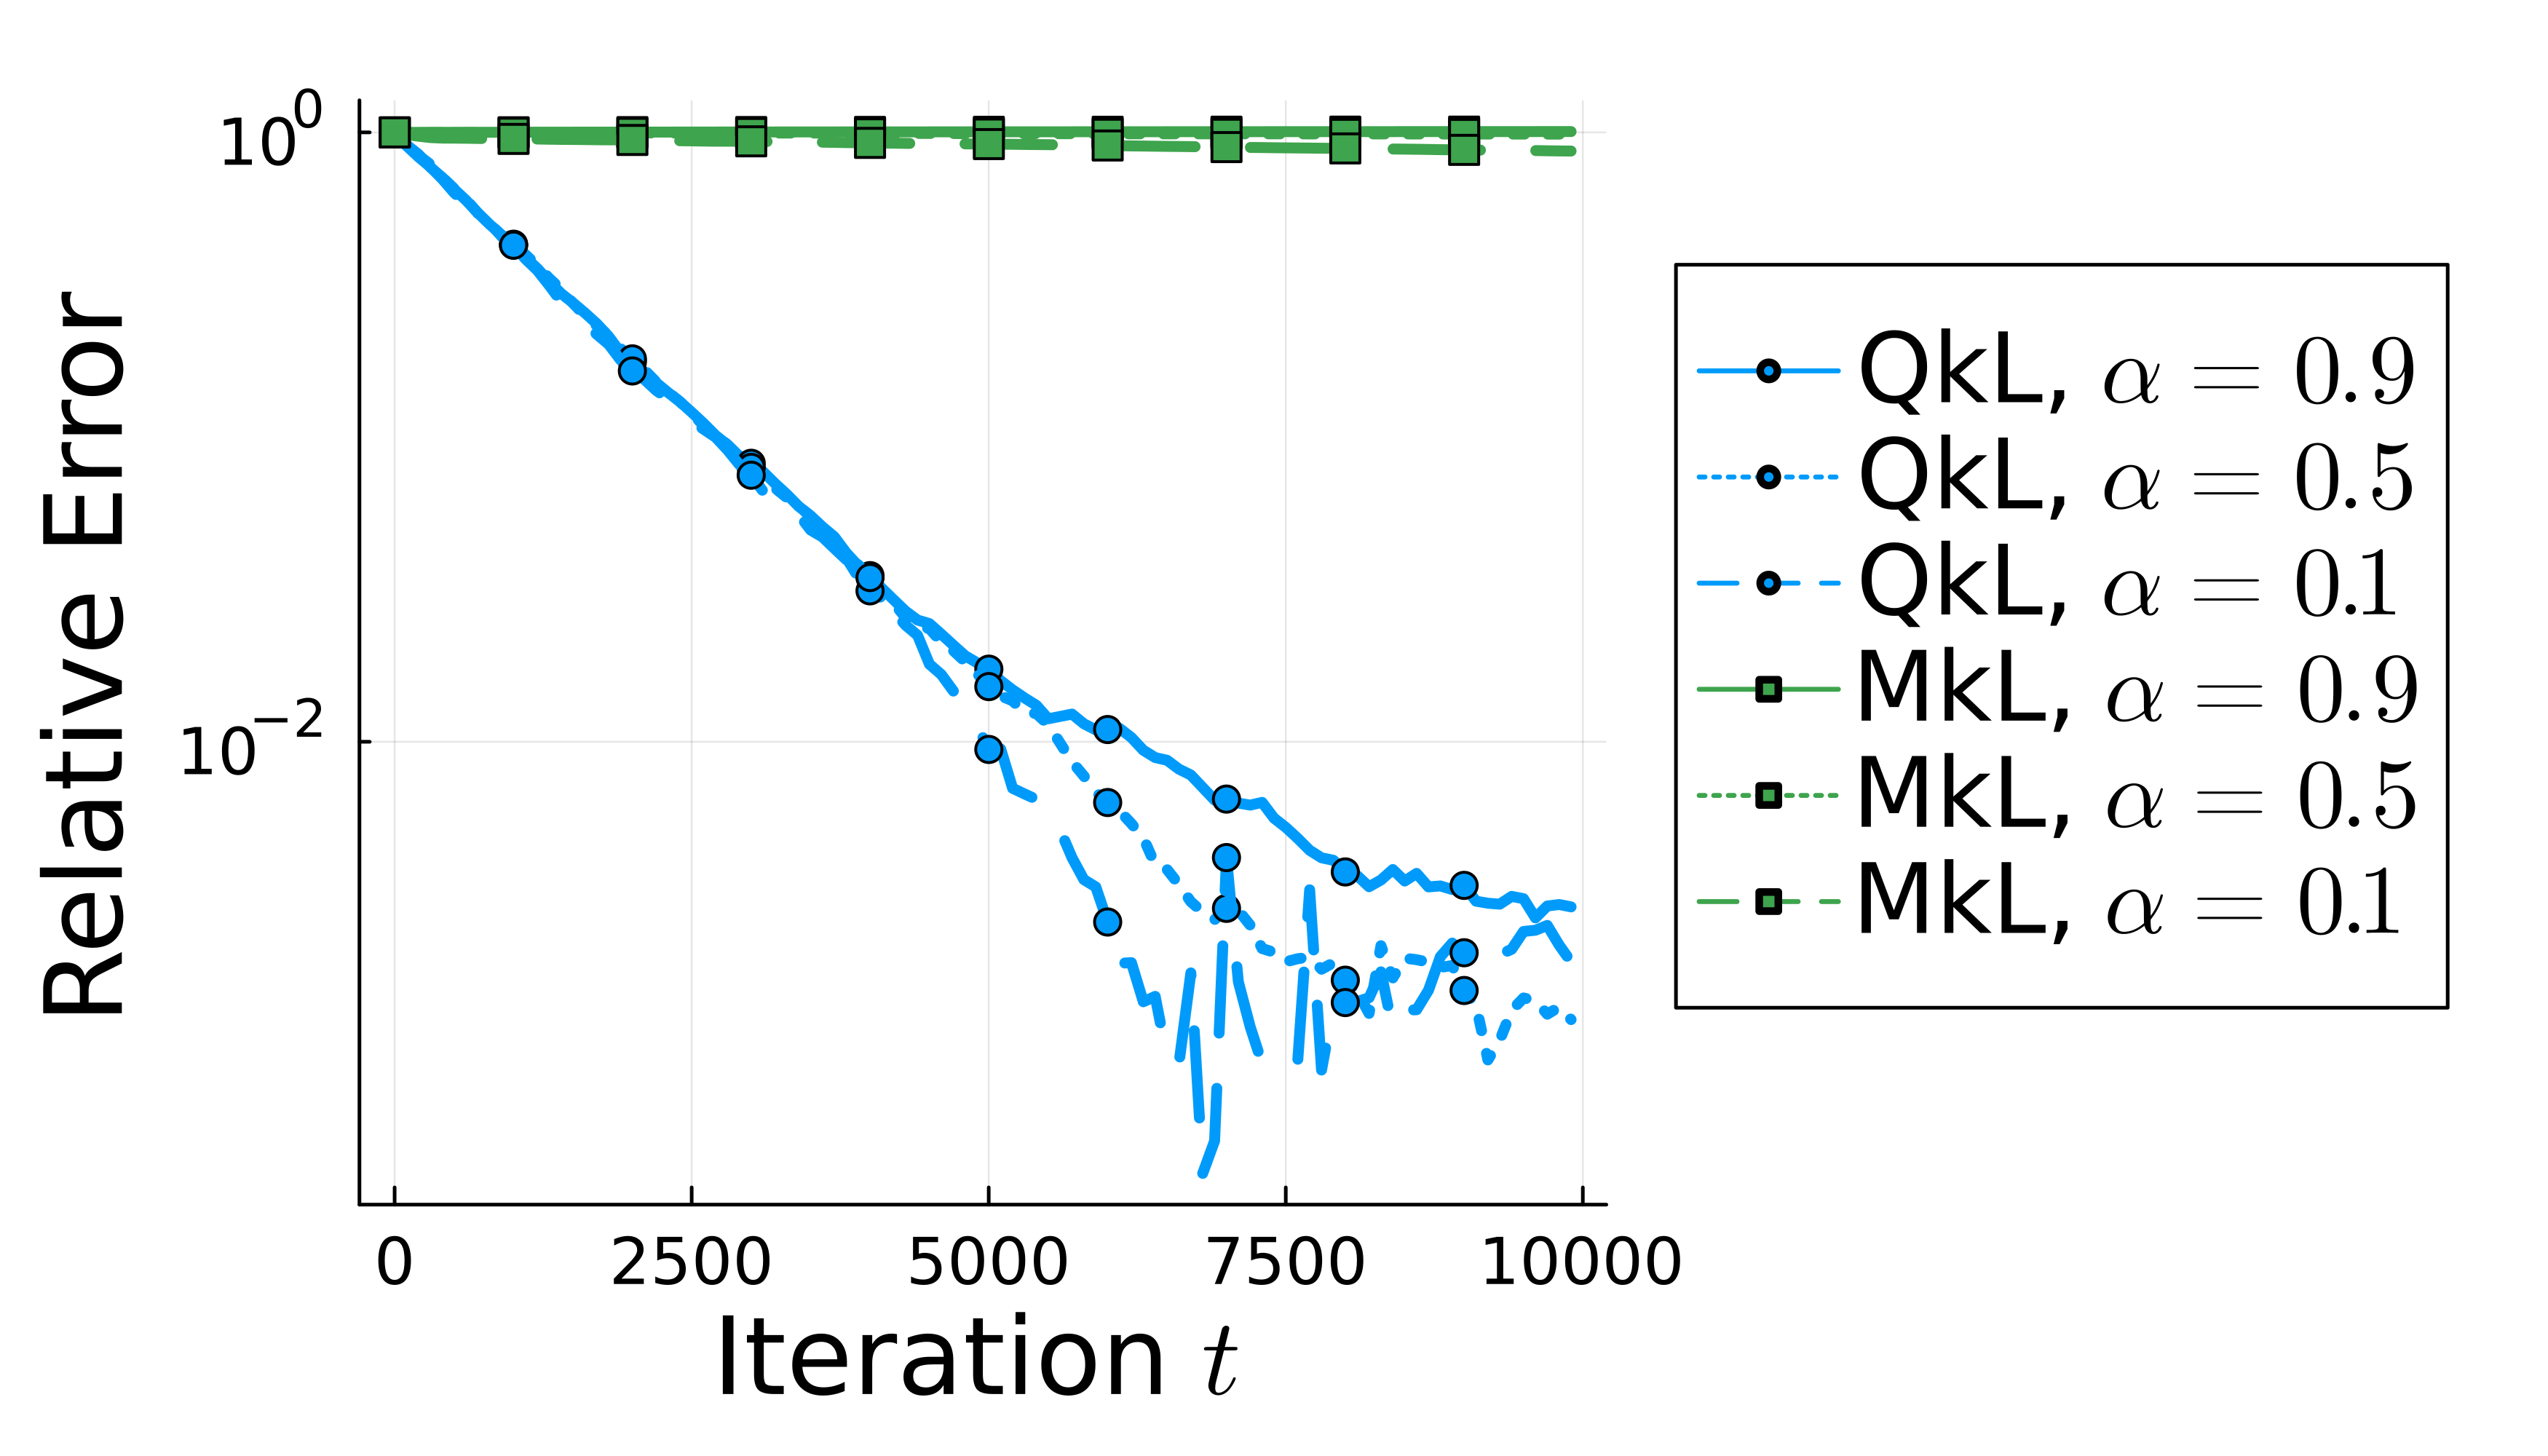

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_error_varyalpha_5percoutlier.png"

In [18]:
# Plot errors
p = plot(iters[1:100:end],qklsgd_error9[1:100:end]/qklsgd_error9[1], label=nothing, xlabel=L"Iteration $t$", ylabel="Relative Error", lw=3, dpi=500,margin=5mm,yscale=:log10,color=1,legend=:outerright,size = (700, 400))
scatter!(iters[1:1000:end],qklsgd_error9[1:1000:end]/qklsgd_error9[1], label=nothing, lw=3,yscale=:log10,color=1)
plot!(iters[1:100:end],qklsgd_error5[1:100:end]/qklsgd_error5[1], label=nothing, lw=3,yscale=:log10,color=1,linestyle=:dot)
scatter!(iters[1:1000:end],qklsgd_error5[1:1000:end]/qklsgd_error5[1], label=nothing, lw=3,yscale=:log10,color=1)
plot!(iters[1:100:end],qklsgd_error1[1:100:end]/qklsgd_error1[1], label=nothing, lw=3,yscale=:log10,color=1,linestyle=:dash)
scatter!(iters[1:1000:end],qklsgd_error1[1:1000:end]/qklsgd_error1[1], label=nothing, lw=3,yscale=:log10,color=1)
plot!(iters[1:100:end],mklsgd_error9[1:100:end]/mklsgd_error9[1], label=nothing, lw=3,yscale=:log10,color=3)
scatter!(iters[1:1000:end],mklsgd_error9[1:1000:end]/mklsgd_error9[1], label=nothing, lw=3,yscale=:log10,color=3,marker=:square)
plot!(iters[1:100:end],mklsgd_error5[1:100:end]/mklsgd_error5[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dot)
scatter!(iters[1:1000:end],mklsgd_error5[1:1000:end]/mklsgd_error5[1], label=nothing, lw=3,yscale=:log10,color=3,marker=:square)
plot!(iters[1:100:end],mklsgd_error1[1:100:end]/mklsgd_error1[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dash)
scatter!(iters[1:1000:end],mklsgd_error1[1:1000:end]/mklsgd_error1[1], label=nothing, lw=3,yscale=:log10,color=3,marker=:square)
# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label=L"QkL, $\alpha = 0.9$", linestyle=:solid, lw=0.6, color=1,marker=:circle)
plot!([NaN], [NaN], label=L"QkL, $\alpha = 0.5$", linestyle=:dot, lw=0.6, color=1,marker=:circle)
plot!([NaN], [NaN], label=L"QkL, $\alpha = 0.1$", linestyle=:dash, lw=0.6, color=1,marker=:circle)
plot!([NaN], [NaN], label=L"MkL, $\alpha = 0.9$", linestyle=:solid, lw=0.6, color=3,marker=:square)
plot!([NaN], [NaN], label=L"MkL, $\alpha = 0.5$", linestyle=:dot, lw=0.6, color=3,marker=:square)
plot!([NaN], [NaN], label=L"MkL, $\alpha = 0.1$", linestyle=:dash, lw=0.6, color=3,marker=:square)

display(p)
savefig("figs/polyregression_error_varyalpha_5percoutlier.png")

## Very small sample size

In [19]:
# Train model with QkL-SGD
qklsgd_x, qkl_G_loss_hist, O_loss_hist, indices, O_allowed, qklsgd_error = qklsgd_poly(x0, D, t, 200, 0.95, Gset, Oset, iters=10000, xstar = coeffs)

# Train model with MkL-SGD
mklsgd_x, mkl_G_loss_hist2, O_loss_hist, indices, O_allowed, mklsgd_error2 = mklsgd_poly(x0, D, t, 2, Gset, Oset, iters=1000000, xstar = coeffs)
mklsgd_x, mkl_G_loss_hist5, O_loss_hist, indices, O_allowed, mklsgd_error5 = mklsgd_poly(x0, D, t, 5, Gset, Oset, iters=400000, xstar = coeffs)
mklsgd_x, mkl_G_loss_hist10, O_loss_hist, indices, O_allowed, mklsgd_error10 = mklsgd_poly(x0, D, t, 10, Gset, Oset, iters=200000, xstar = coeffs)

([0.9695495032587651, 0.46195345883021893, -0.2003286427263316, 0.055735586354767594], [229.92624515046833, 230.7087291845017, 227.5711773879938, 229.69675497790666, 229.5950647412979, 227.51589410187634, 227.67706330247228, 225.68299253457866, 226.46129713438108, 226.9070469087535  …  9.862605464012573, 9.863322644608017, 9.85238208158703, 9.852332088303257, 9.67133480447518, 9.66024319780828, 9.657816592951585, 9.6605710714777, 9.68506986666155, 9.682229487996102], [164.0061618511119, 163.94647805857844, 164.11374436974774, 163.91546686245502, 163.9238347050226, 164.040145976499, 164.0225379959823, 164.1350465606821, 164.0746534569632, 164.00116625382194  …  162.02936685361166, 162.0092295855997, 162.0088099236467, 161.9855063273315, 162.34680611873205, 162.25972508906392, 162.23277180504422, 162.2450307318328, 162.42123337188573, 162.4239634775517], [64, 38, 71, 67, 43, 75, 43, 64, 82, 75  …  64, 131, 69, 196, 14, 11, 76, 10, 139, 95], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0  …  0, 0, 0, 0, 0

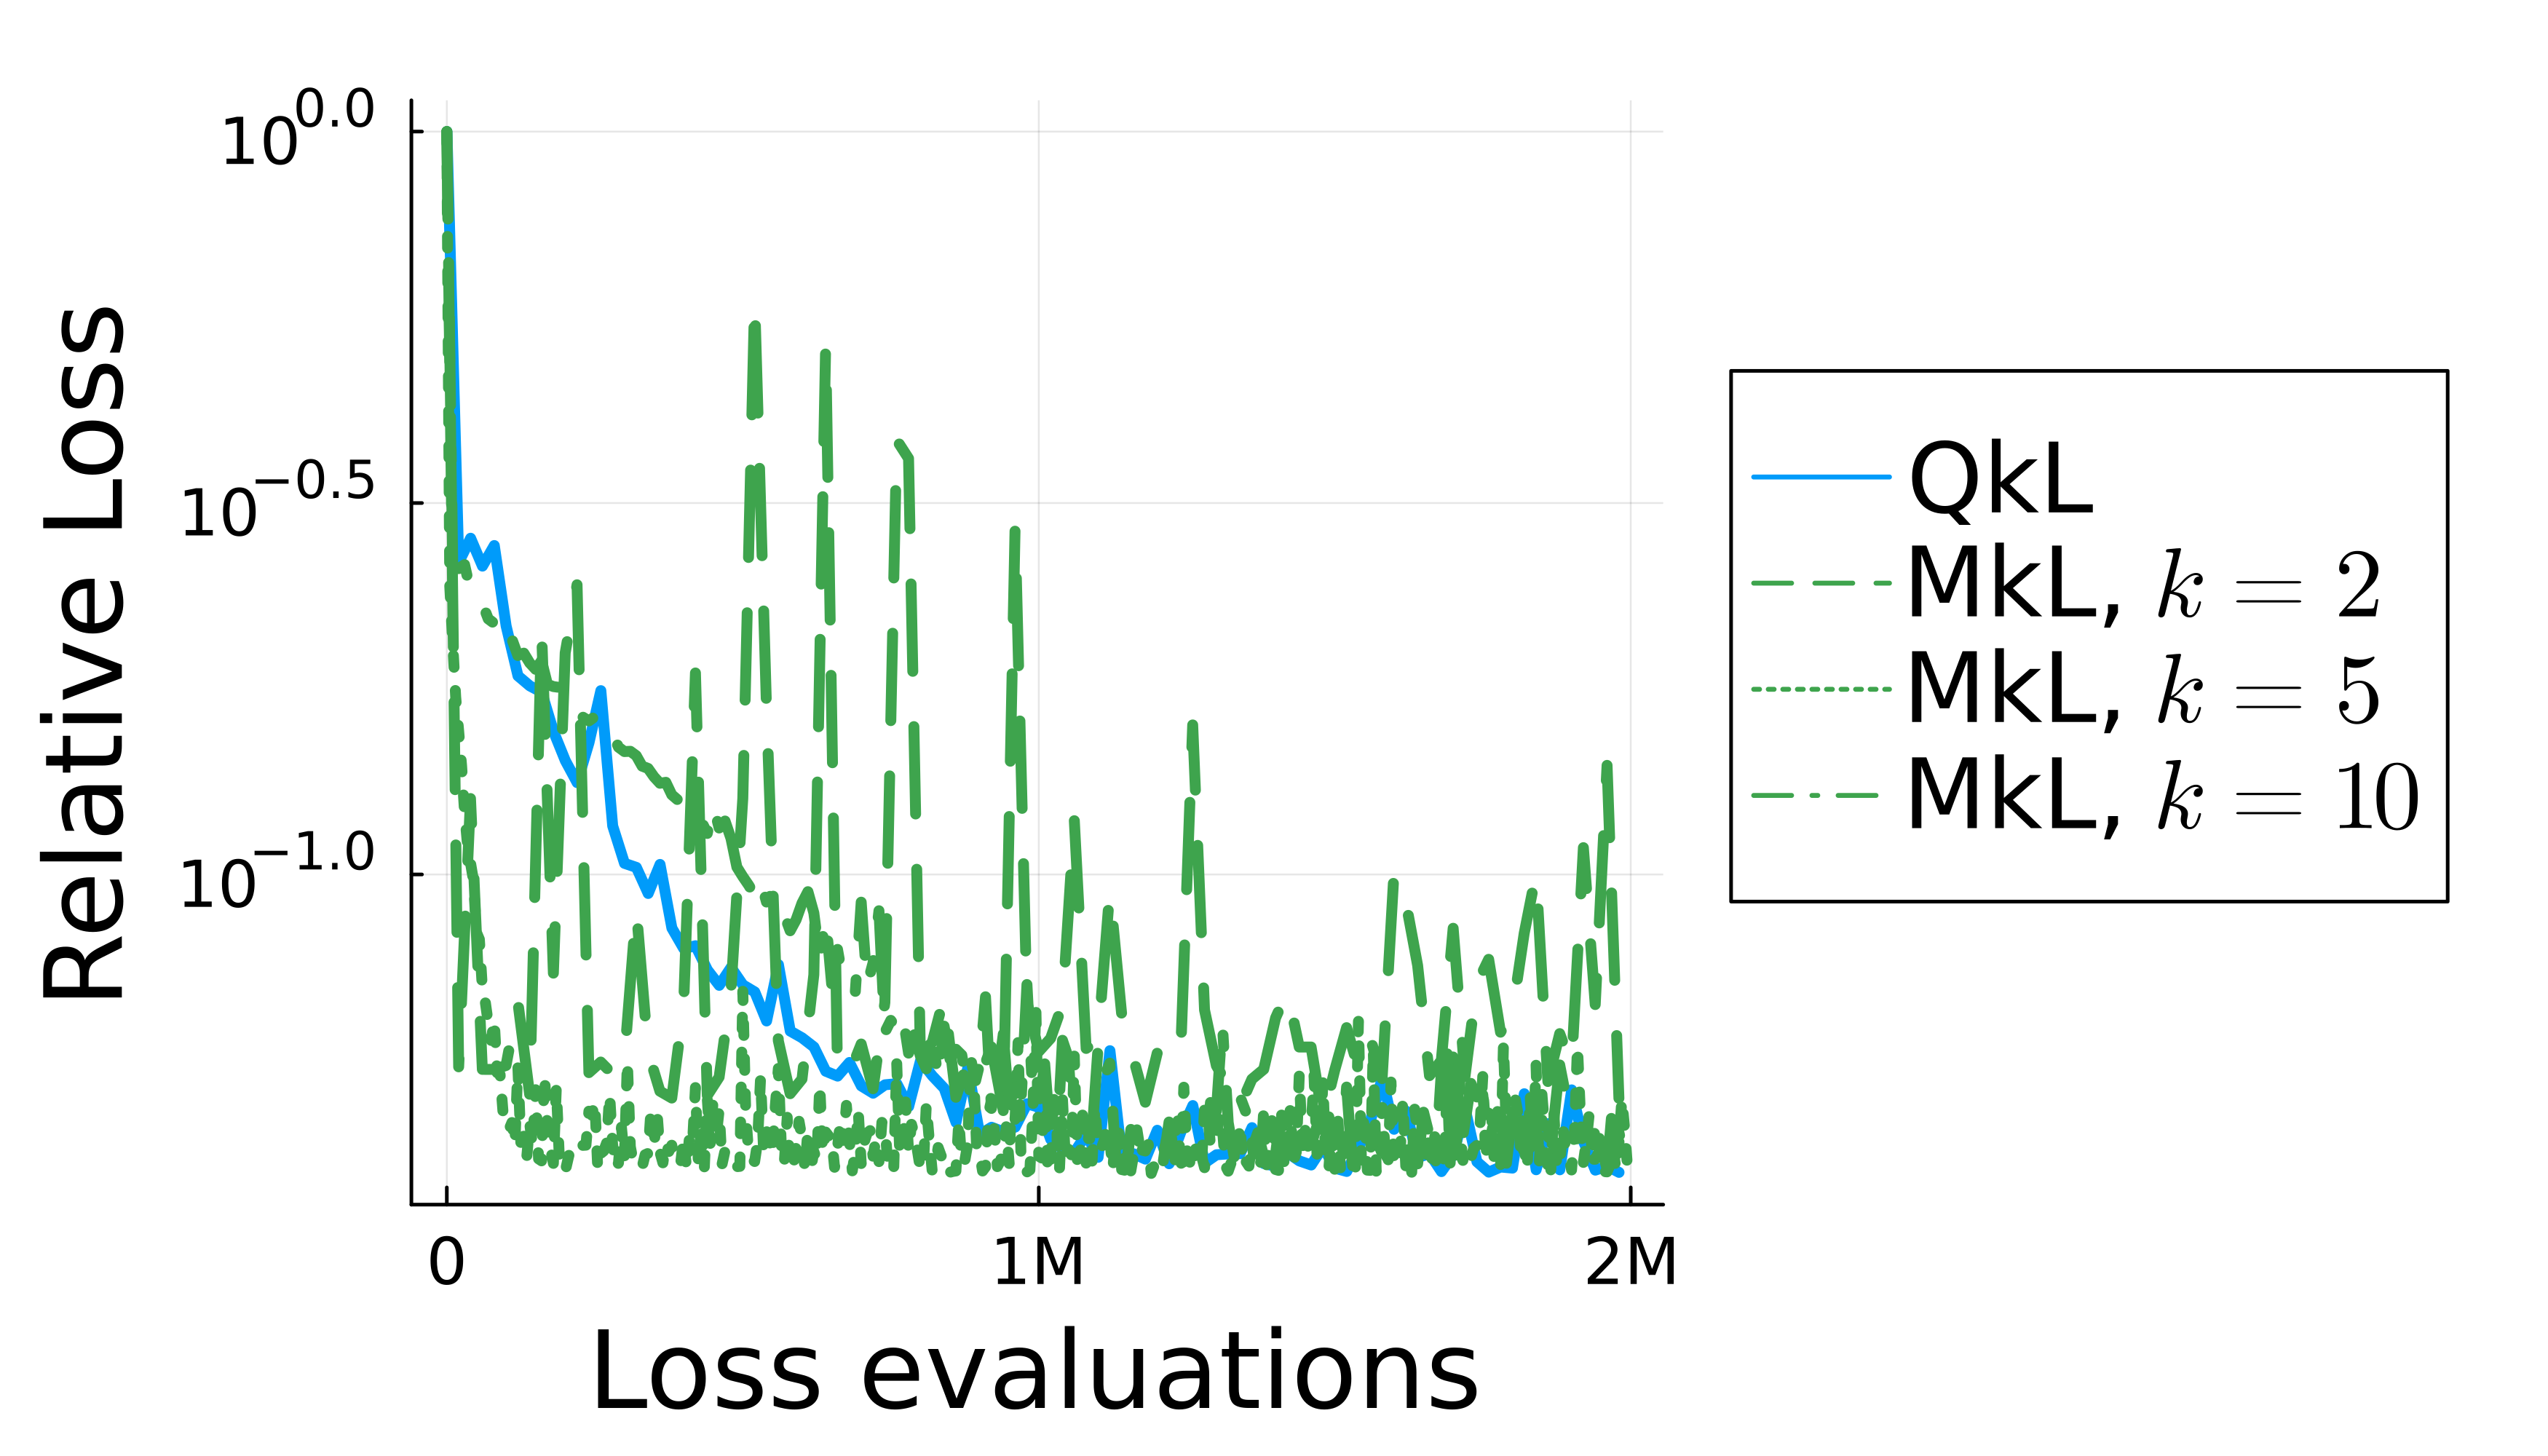

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_loss_smallk_5percoutlier.png"

In [20]:
iters = 1:10000

# Plot loss curve
p = plot(200*iters[1:100:end],qkl_G_loss_hist[1:100:end]/qkl_G_loss_hist[1], label=nothing, xlabel="Loss evaluations", ylabel="Relative Loss", lw=3, dpi=500,margin=5mm,yscale=:log10,color=1,legend=:outerright,size = (700, 400))
iters = 1:1000000
plot!(2*iters[1:10000:end],mkl_G_loss_hist2[1:10000:end]/mkl_G_loss_hist2[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dash)
iters = 1:400000
plot!(5*iters[1:1000:end],mkl_G_loss_hist5[1:1000:end]/mkl_G_loss_hist5[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dot)
iters = 1:200000
plot!(10*iters[1:1000:end],mkl_G_loss_hist10[1:1000:end]/mkl_G_loss_hist10[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dashdot)
xticks!([0,1000000,2000000],["0","1M","2M"])
# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="QkL", linestyle=:solid, lw=0.6, color=1)
plot!([NaN], [NaN], label=L"MkL, $k = 2$", linestyle=:dash, lw=0.6, color=3)
plot!([NaN], [NaN], label=L"MkL, $k = 5$", linestyle=:dot, lw=0.6, color=3)
plot!([NaN], [NaN], label=L"MkL, $k = 10$", linestyle=:dashdot, lw=0.6, color=3)

display(p)
savefig("figs/polyregression_loss_smallk_5percoutlier.png")

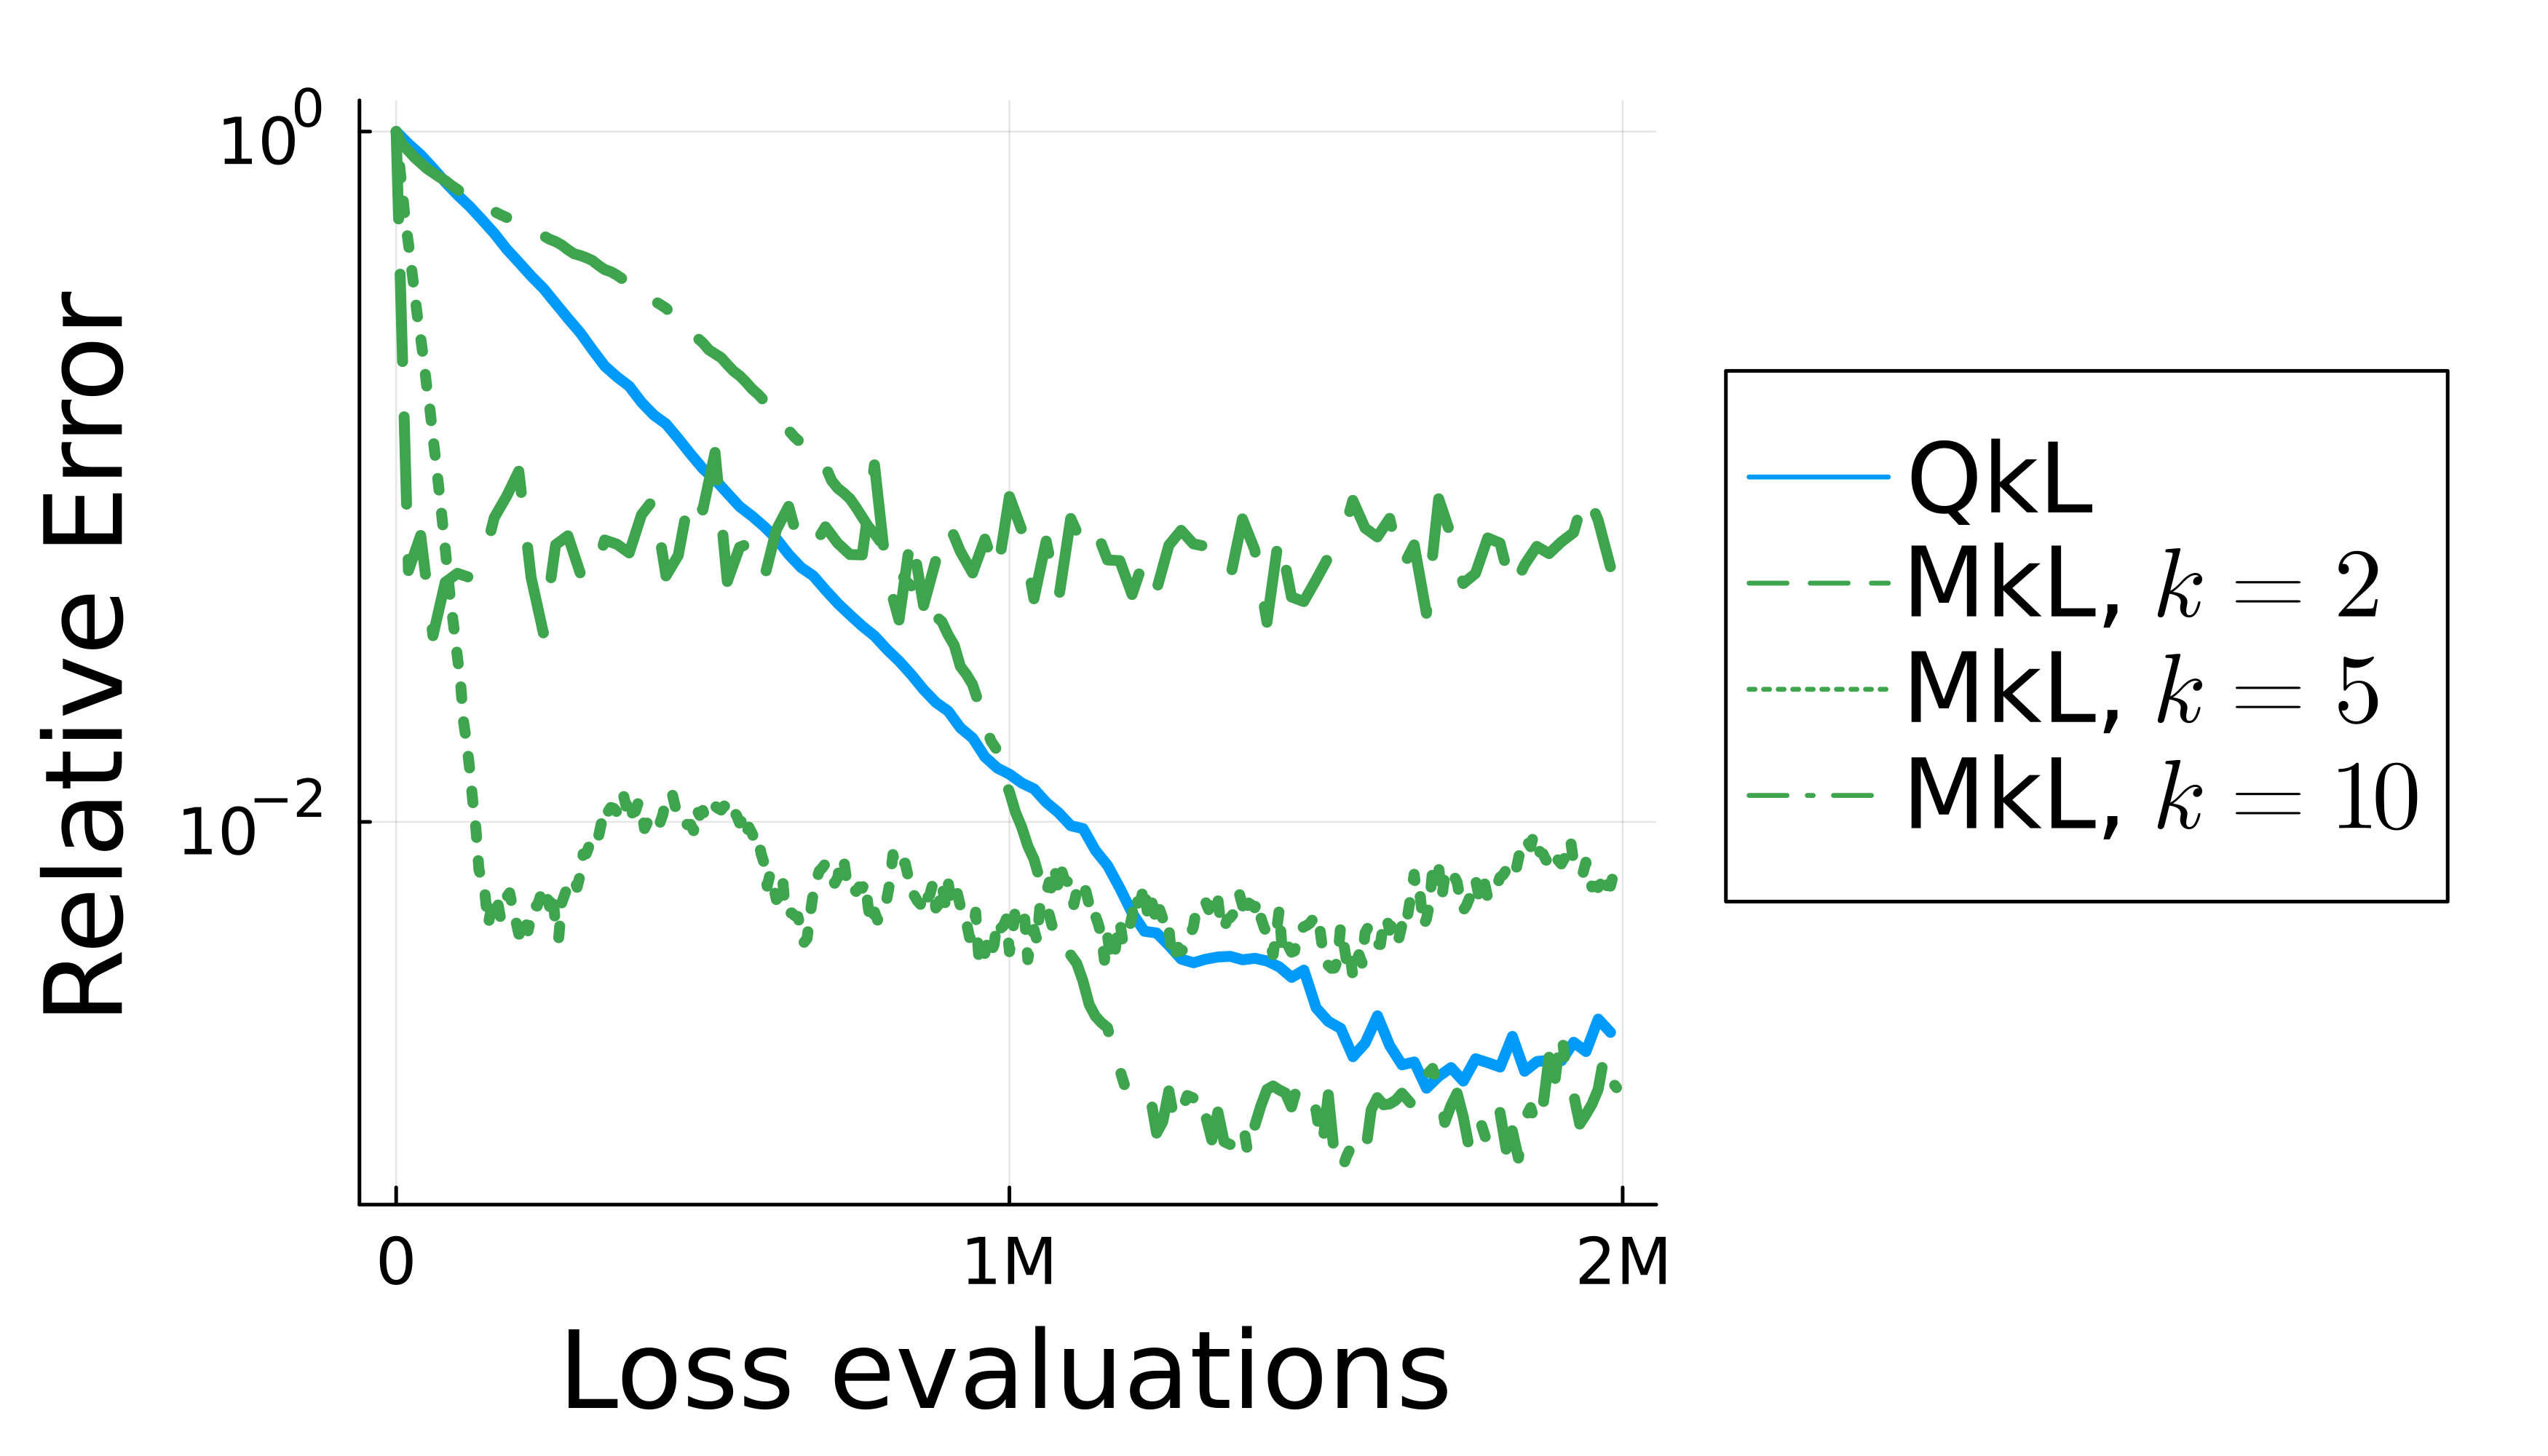

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_error_smallk_5percoutlier.png"

In [21]:
iters = 1:10000

# Plot errors
p = plot(200*iters[1:100:end],qklsgd_error[1:100:end]/qklsgd_error[1], label=nothing, xlabel="Loss evaluations", ylabel="Relative Error", lw=3, dpi=500,margin=5mm,yscale=:log10,color=1,legend=:outerright,size = (700, 400))
iters = 1:1000000
plot!(2*iters[1:10000:end],mklsgd_error2[1:10000:end]/mklsgd_error2[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dash)
iters = 1:400000
plot!(5*iters[1:1000:end],mklsgd_error5[1:1000:end]/mklsgd_error5[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dot)
iters = 1:200000
plot!(10*iters[1:1000:end],mklsgd_error10[1:1000:end]/mklsgd_error10[1], label=nothing, lw=3,yscale=:log10,color=3,linestyle=:dashdot)
xticks!([0,1000000,2000000],["0","1M","2M"])

# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="QkL", linestyle=:solid, lw=0.6, color=1)
plot!([NaN], [NaN], label=L"MkL, $k = 2$", linestyle=:dash, lw=0.6, color=3)
plot!([NaN], [NaN], label=L"MkL, $k = 5$", linestyle=:dot, lw=0.6, color=3)
plot!([NaN], [NaN], label=L"MkL, $k = 10$", linestyle=:dashdot, lw=0.6, color=3)

display(p)
savefig("figs/polyregression_error_smallk_5percoutlier.png")

# Sample size vs Final Relative Error

In [22]:
num_trials = 100
alphas = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
num_alphas = length(alphas)

qkl_relative_errors = zeros(num_trials, num_alphas)
mkl_relative_errors = zeros(num_trials, num_alphas)
qkl_relative_losses = zeros(num_trials, num_alphas)
mkl_relative_losses = zeros(num_trials, num_alphas)

iters = 10000
for trial = 1:num_trials

    alpha = 1.0
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist10, O_loss_hist, indices, O_allowed, qklsgd_error10 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist10, O_loss_hist, indices, O_allowed, mklsgd_error10 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.95
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist95, O_loss_hist, indices, O_allowed, qklsgd_error95 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist95, O_loss_hist, indices, O_allowed, mklsgd_error95 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.9
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist9, O_loss_hist, indices, O_allowed, qklsgd_error9 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist9, O_loss_hist, indices, O_allowed, mklsgd_error9 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.8
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist8, O_loss_hist, indices, O_allowed, qklsgd_error8 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist8, O_loss_hist, indices, O_allowed, mklsgd_error8 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.7
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist7, O_loss_hist, indices, O_allowed, qklsgd_error7 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist7, O_loss_hist, indices, O_allowed, mklsgd_error7 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.6
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist6, O_loss_hist, indices, O_allowed, qklsgd_error6 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist6, O_loss_hist, indices, O_allowed, mklsgd_error6 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.5
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist5, O_loss_hist, indices, O_allowed, qklsgd_error5 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist5, O_loss_hist, indices, O_allowed, mklsgd_error5 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.4
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist4, O_loss_hist, indices, O_allowed, qklsgd_error4 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist4, O_loss_hist, indices, O_allowed, mklsgd_error4 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.3
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist3, O_loss_hist, indices, O_allowed, qklsgd_error3 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist3, O_loss_hist, indices, O_allowed, mklsgd_error3 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.2
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist2, O_loss_hist, indices, O_allowed, qklsgd_error2 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist2, O_loss_hist, indices, O_allowed, mklsgd_error2 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.1
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist1, O_loss_hist, indices, O_allowed, qklsgd_error1 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist1, O_loss_hist, indices, O_allowed, mklsgd_error1 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    alpha = 0.05
    # Train model with QkL-SGD
    qklsgd_x, qkl_G_loss_hist05, O_loss_hist, indices, O_allowed, qklsgd_error05 = qklsgd_poly(x0, D, t, Int(alpha*200), 0.95, Gset, Oset, iters=10000, xstar = coeffs)

    # Train model with MkL-SGD
    mklsgd_x, mkl_G_loss_hist05, O_loss_hist, indices, O_allowed, mklsgd_error05 = mklsgd_poly(x0, D, t, Int(alpha*200), Gset, Oset, iters=10000, xstar = coeffs)

    qkl_relative_losses[trial,:] = [qkl_G_loss_hist05[iters]/qkl_G_loss_hist05[1], qkl_G_loss_hist1[iters]/qkl_G_loss_hist1[1], qkl_G_loss_hist2[iters]/qkl_G_loss_hist2[1], qkl_G_loss_hist3[iters]/qkl_G_loss_hist3[1], qkl_G_loss_hist4[iters]/qkl_G_loss_hist4[1], qkl_G_loss_hist5[iters]/qkl_G_loss_hist5[1], qkl_G_loss_hist6[iters]/qkl_G_loss_hist6[1], qkl_G_loss_hist7[iters]/qkl_G_loss_hist7[1], qkl_G_loss_hist8[iters]/qkl_G_loss_hist8[1], qkl_G_loss_hist9[iters]/qkl_G_loss_hist9[1], qkl_G_loss_hist95[iters]/qkl_G_loss_hist95[1], qkl_G_loss_hist10[iters]/qkl_G_loss_hist10[1]]
    mkl_relative_losses[trial,:] = [mkl_G_loss_hist05[iters]/mkl_G_loss_hist05[1], mkl_G_loss_hist1[iters]/mkl_G_loss_hist1[1], mkl_G_loss_hist2[iters]/mkl_G_loss_hist2[1], mkl_G_loss_hist3[iters]/mkl_G_loss_hist3[1], mkl_G_loss_hist4[iters]/mkl_G_loss_hist4[1], mkl_G_loss_hist5[iters]/mkl_G_loss_hist5[1], mkl_G_loss_hist6[iters]/mkl_G_loss_hist6[1], mkl_G_loss_hist7[iters]/mkl_G_loss_hist7[1], mkl_G_loss_hist8[iters]/mkl_G_loss_hist8[1], mkl_G_loss_hist9[iters]/mkl_G_loss_hist9[1], mkl_G_loss_hist95[iters]/mkl_G_loss_hist95[1], mkl_G_loss_hist10[iters]/mkl_G_loss_hist10[1]]

    qkl_relative_errors[trial,:] = [qklsgd_error05[iters]/qklsgd_error05[1], qklsgd_error1[iters]/qklsgd_error1[1], qklsgd_error2[iters]/qklsgd_error2[1], qklsgd_error3[iters]/qklsgd_error3[1], qklsgd_error4[iters]/qklsgd_error4[1], qklsgd_error5[iters]/qklsgd_error5[1], qklsgd_error6[iters]/qklsgd_error6[1], qklsgd_error7[iters]/qklsgd_error7[1], qklsgd_error8[iters]/qklsgd_error8[1], qklsgd_error9[iters]/qklsgd_error9[1], qklsgd_error95[iters]/qklsgd_error95[1], qklsgd_error10[iters]/qklsgd_error10[1]]
    mkl_relative_errors[trial,:] = [mklsgd_error05[iters]/mklsgd_error05[1], mklsgd_error1[iters]/mklsgd_error1[1], mklsgd_error2[iters]/mklsgd_error2[1], mklsgd_error3[iters]/mklsgd_error3[1], mklsgd_error4[iters]/mklsgd_error4[1], mklsgd_error5[iters]/mklsgd_error5[1], mklsgd_error6[iters]/mklsgd_error6[1], mklsgd_error7[iters]/mklsgd_error7[1], mklsgd_error8[iters]/mklsgd_error8[1], mklsgd_error9[iters]/mklsgd_error9[1], mklsgd_error95[iters]/mklsgd_error95[1], mklsgd_error10[iters]/mklsgd_error10[1]]
end

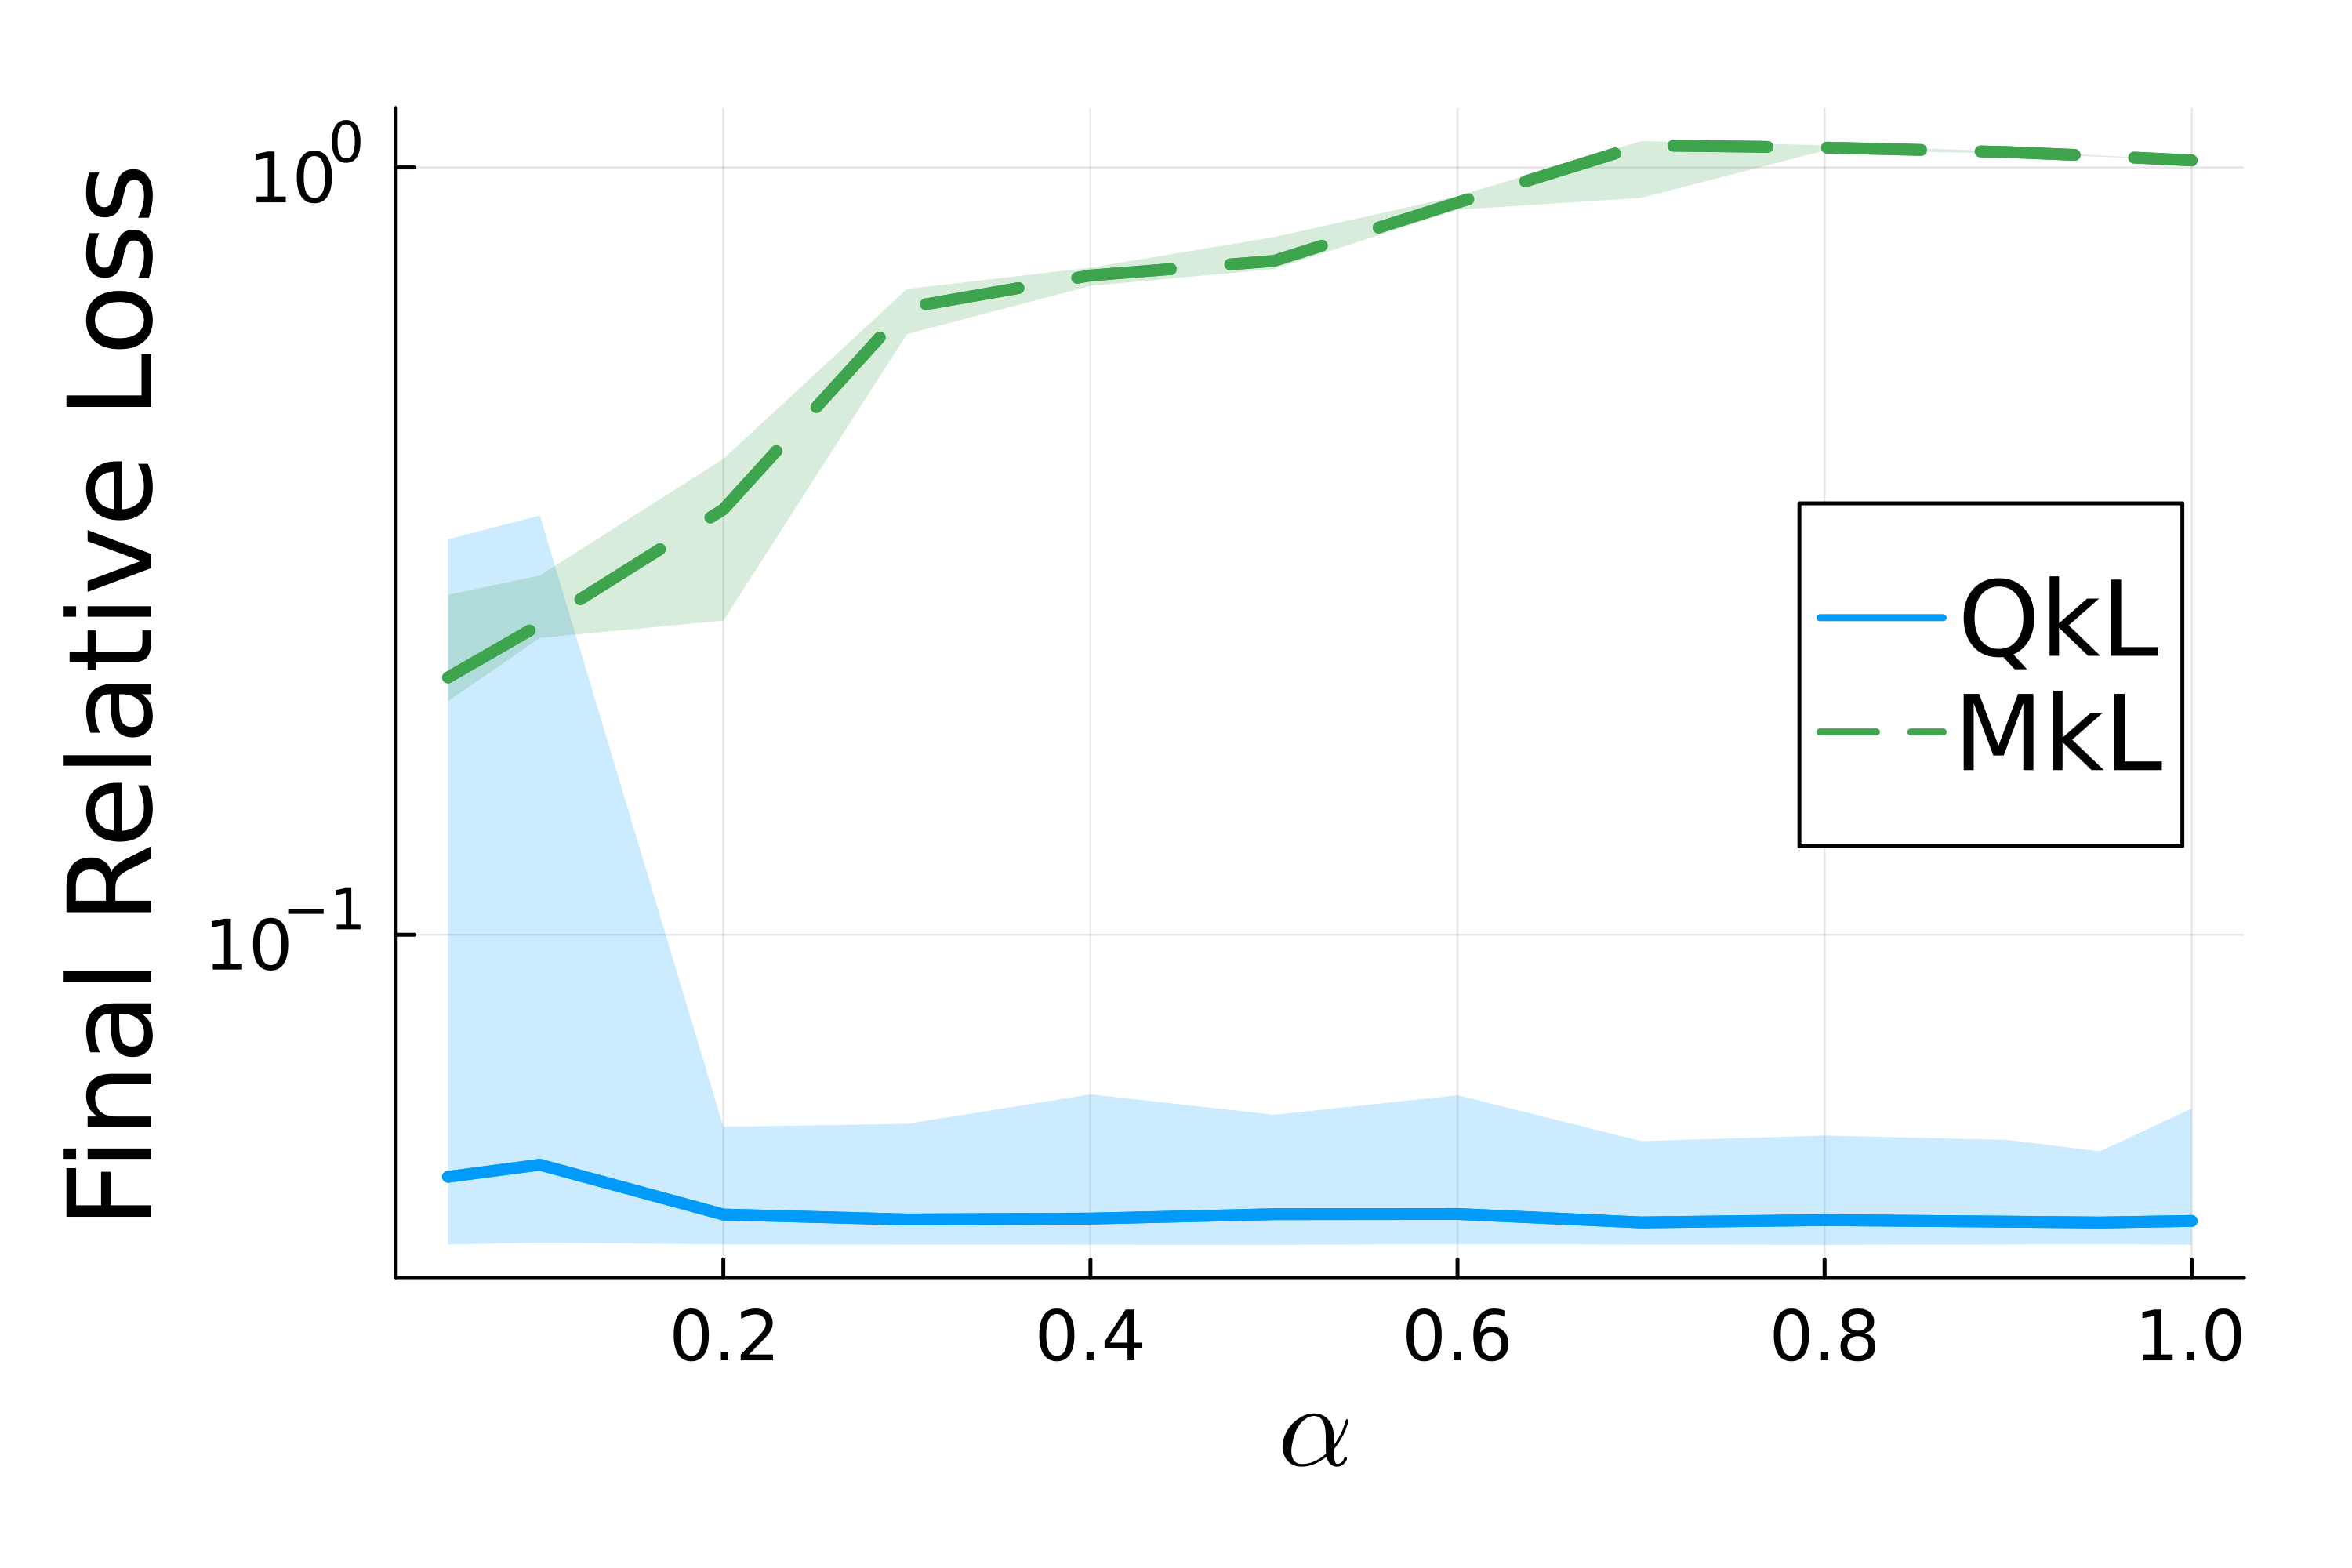

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_loss_vs_alpha_5percoutlier.png"

In [23]:
p = plot(alphas, vec(mean(qkl_relative_losses, dims=1)), fillrange = vec(maximum(qkl_relative_losses, dims=1)), fillalpha = 0.2, label=nothing, xlabel=L"$\alpha$", ylabel="Final Relative Loss", lw=3, dpi=500,margin=5mm,color=1,legend=:right,yscale=:log10)
plot!(alphas, vec(mean(qkl_relative_losses, dims=1)), fillrange = vec(minimum(qkl_relative_losses, dims=1)), fillalpha = 0.2, label=nothing, lw=3, color=1,yscale=:log10)
plot!(alphas, vec(mean(mkl_relative_losses, dims=1)), fillrange = vec(maximum(mkl_relative_losses, dims=1)), fillalpha = 0.2, label=nothing, lw=3, color=3,linestyle=:dash,yscale=:log10)
plot!(alphas, vec(mean(mkl_relative_losses, dims=1)), fillrange = vec(minimum(mkl_relative_losses, dims=1)), fillalpha = 0.2, label=nothing, lw=3, color=3,linestyle=:dash,yscale=:log10)
# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="QkL", linestyle=:solid, lw=0.8, color=1)
plot!([NaN], [NaN], label="MkL", linestyle=:dash, lw=0.8, color=3)

display(p)
savefig("figs/polyregression_loss_vs_alpha_5percoutlier.png")

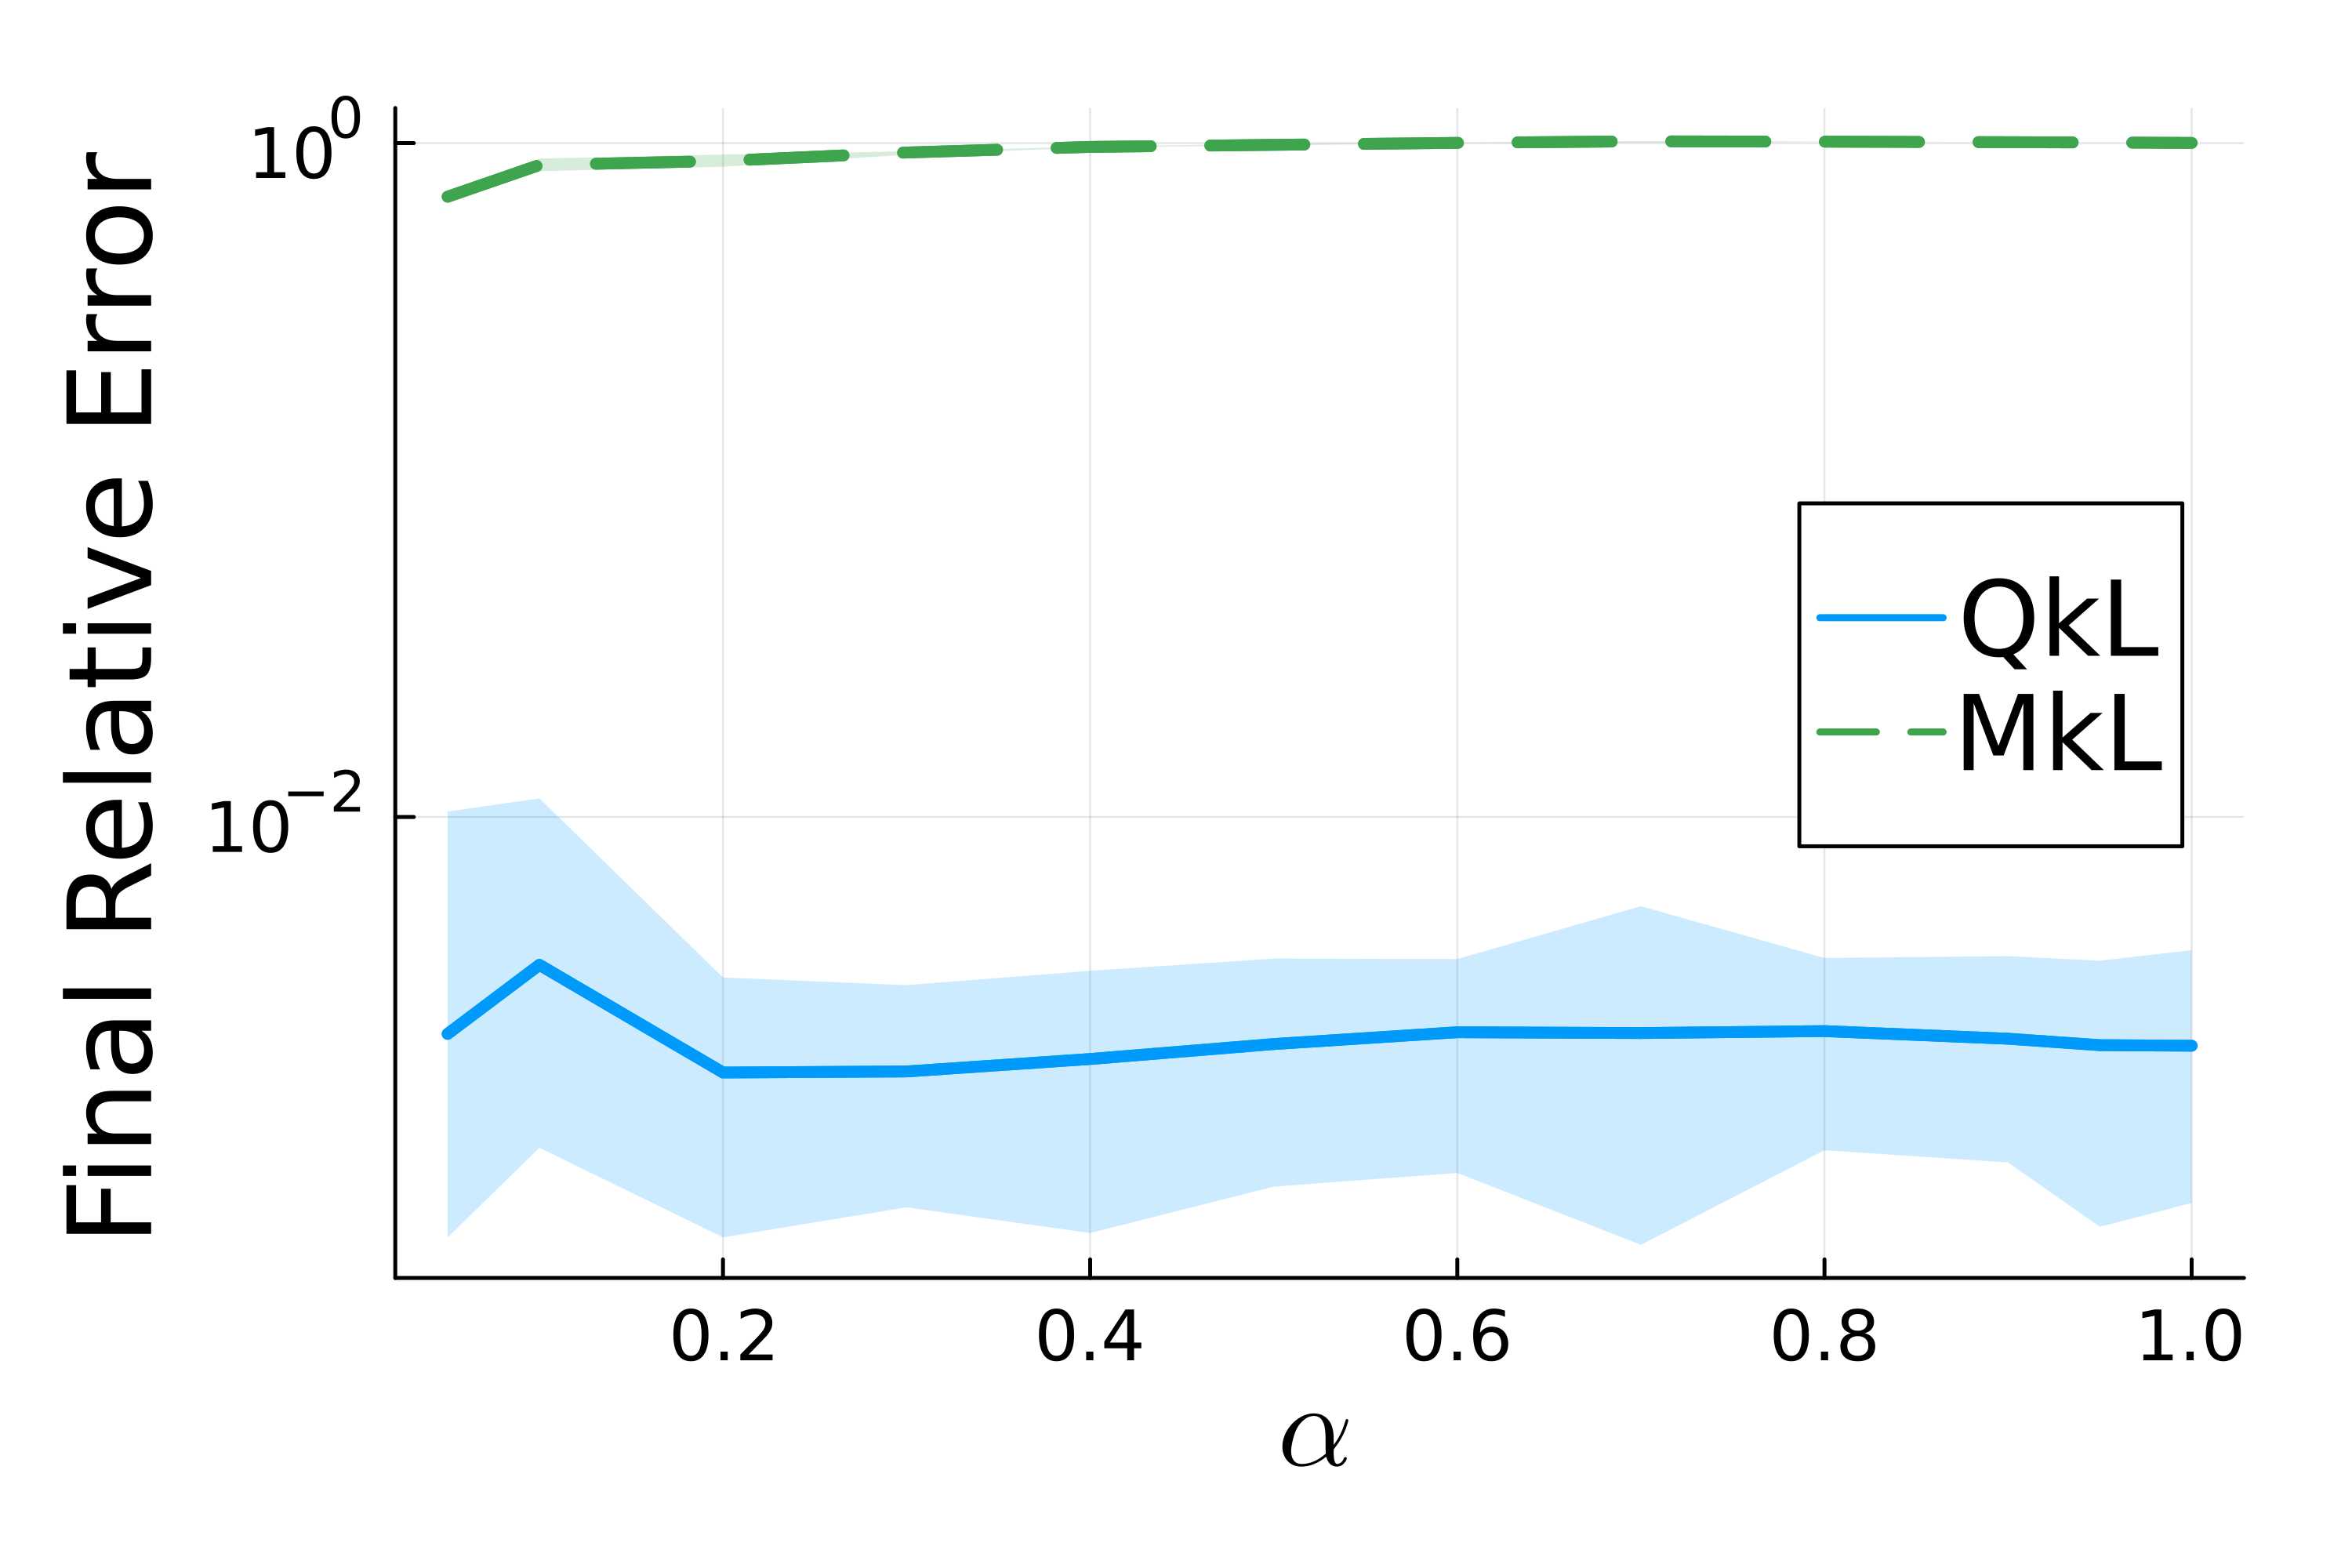

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_error_vs_alpha_5percoutlier.png"

In [24]:
p = plot(alphas, vec(mean(qkl_relative_errors, dims=1)), fillrange = vec(maximum(qkl_relative_errors, dims=1)), fillalpha = 0.2, label=nothing, xlabel=L"$\alpha$", ylabel="Final Relative Error", lw=3, dpi=500,margin=5mm,color=1,legend=:right,yscale=:log10)
plot!(alphas, vec(mean(qkl_relative_errors, dims=1)), fillrange = vec(minimum(qkl_relative_errors, dims=1)), fillalpha = 0.2, label=nothing, lw=3, color=1,yscale=:log10)
plot!(alphas, vec(mean(mkl_relative_errors, dims=1)), fillrange = vec(maximum(mkl_relative_errors, dims=1)), fillalpha = 0.2, label=nothing, lw=3, color=3,linestyle=:dash,yscale=:log10)
plot!(alphas, vec(mean(mkl_relative_errors, dims=1)), fillrange = vec(minimum(mkl_relative_errors, dims=1)), fillalpha = 0.2, label=nothing, lw=3, color=3,linestyle=:dash,yscale=:log10)
# Burner plots (only for legend, thin lines)
plot!([NaN], [NaN], label="QkL", linestyle=:solid, lw=0.8, color=1)
plot!([NaN], [NaN], label="MkL", linestyle=:dash, lw=0.8, color=3)

display(p)
savefig("figs/polyregression_error_vs_alpha_5percoutlier.png")

# Quantile vs Final Relative Error

In [25]:
betas = [0.1, 0.2, 0.3, 0.4]
qs = 0.05:0.05:1.0

final_errs = zeros(length(betas), length(qs))
final_losses = zeros(length(betas), length(qs))

num_trials = 100

for (j,β) in enumerate(betas)
    Oset = rand(1:n_samples, Int(β*n_samples))  # Randomly select Oset indices
    t = D * coeffs .+ noise_std * randn(n_samples)
    t[Oset] .= t[Oset] + 10*randn(Int(β*n_samples))
    Gset = setdiff(1:n_samples, Oset);  # Gset is the complement of Oset

    errs = zeros(num_trials, length(qs))
    losses = zeros(num_trials, length(qs))
    for trial = 1:num_trials
        for (i,q) in enumerate(qs)
            # Train model with QkL-SGD
            qklsgd_x, qkl_G_loss_hist, O_loss_hist, indices, O_allowed, qklsgd_error = qklsgd_poly(x0, D, t, n_samples, q, Gset, Oset, iters=10000, xstar = coeffs)

            errs[trial, i] = qklsgd_error[end]/qklsgd_error[1]
            losses[trial, i] = qkl_G_loss_hist[end]/qkl_G_loss_hist[1]
        end
    end
    final_errs[j, :] = vec(mean(errs, dims=1))
    final_losses[j, :] = vec(mean(losses, dims=1))
end

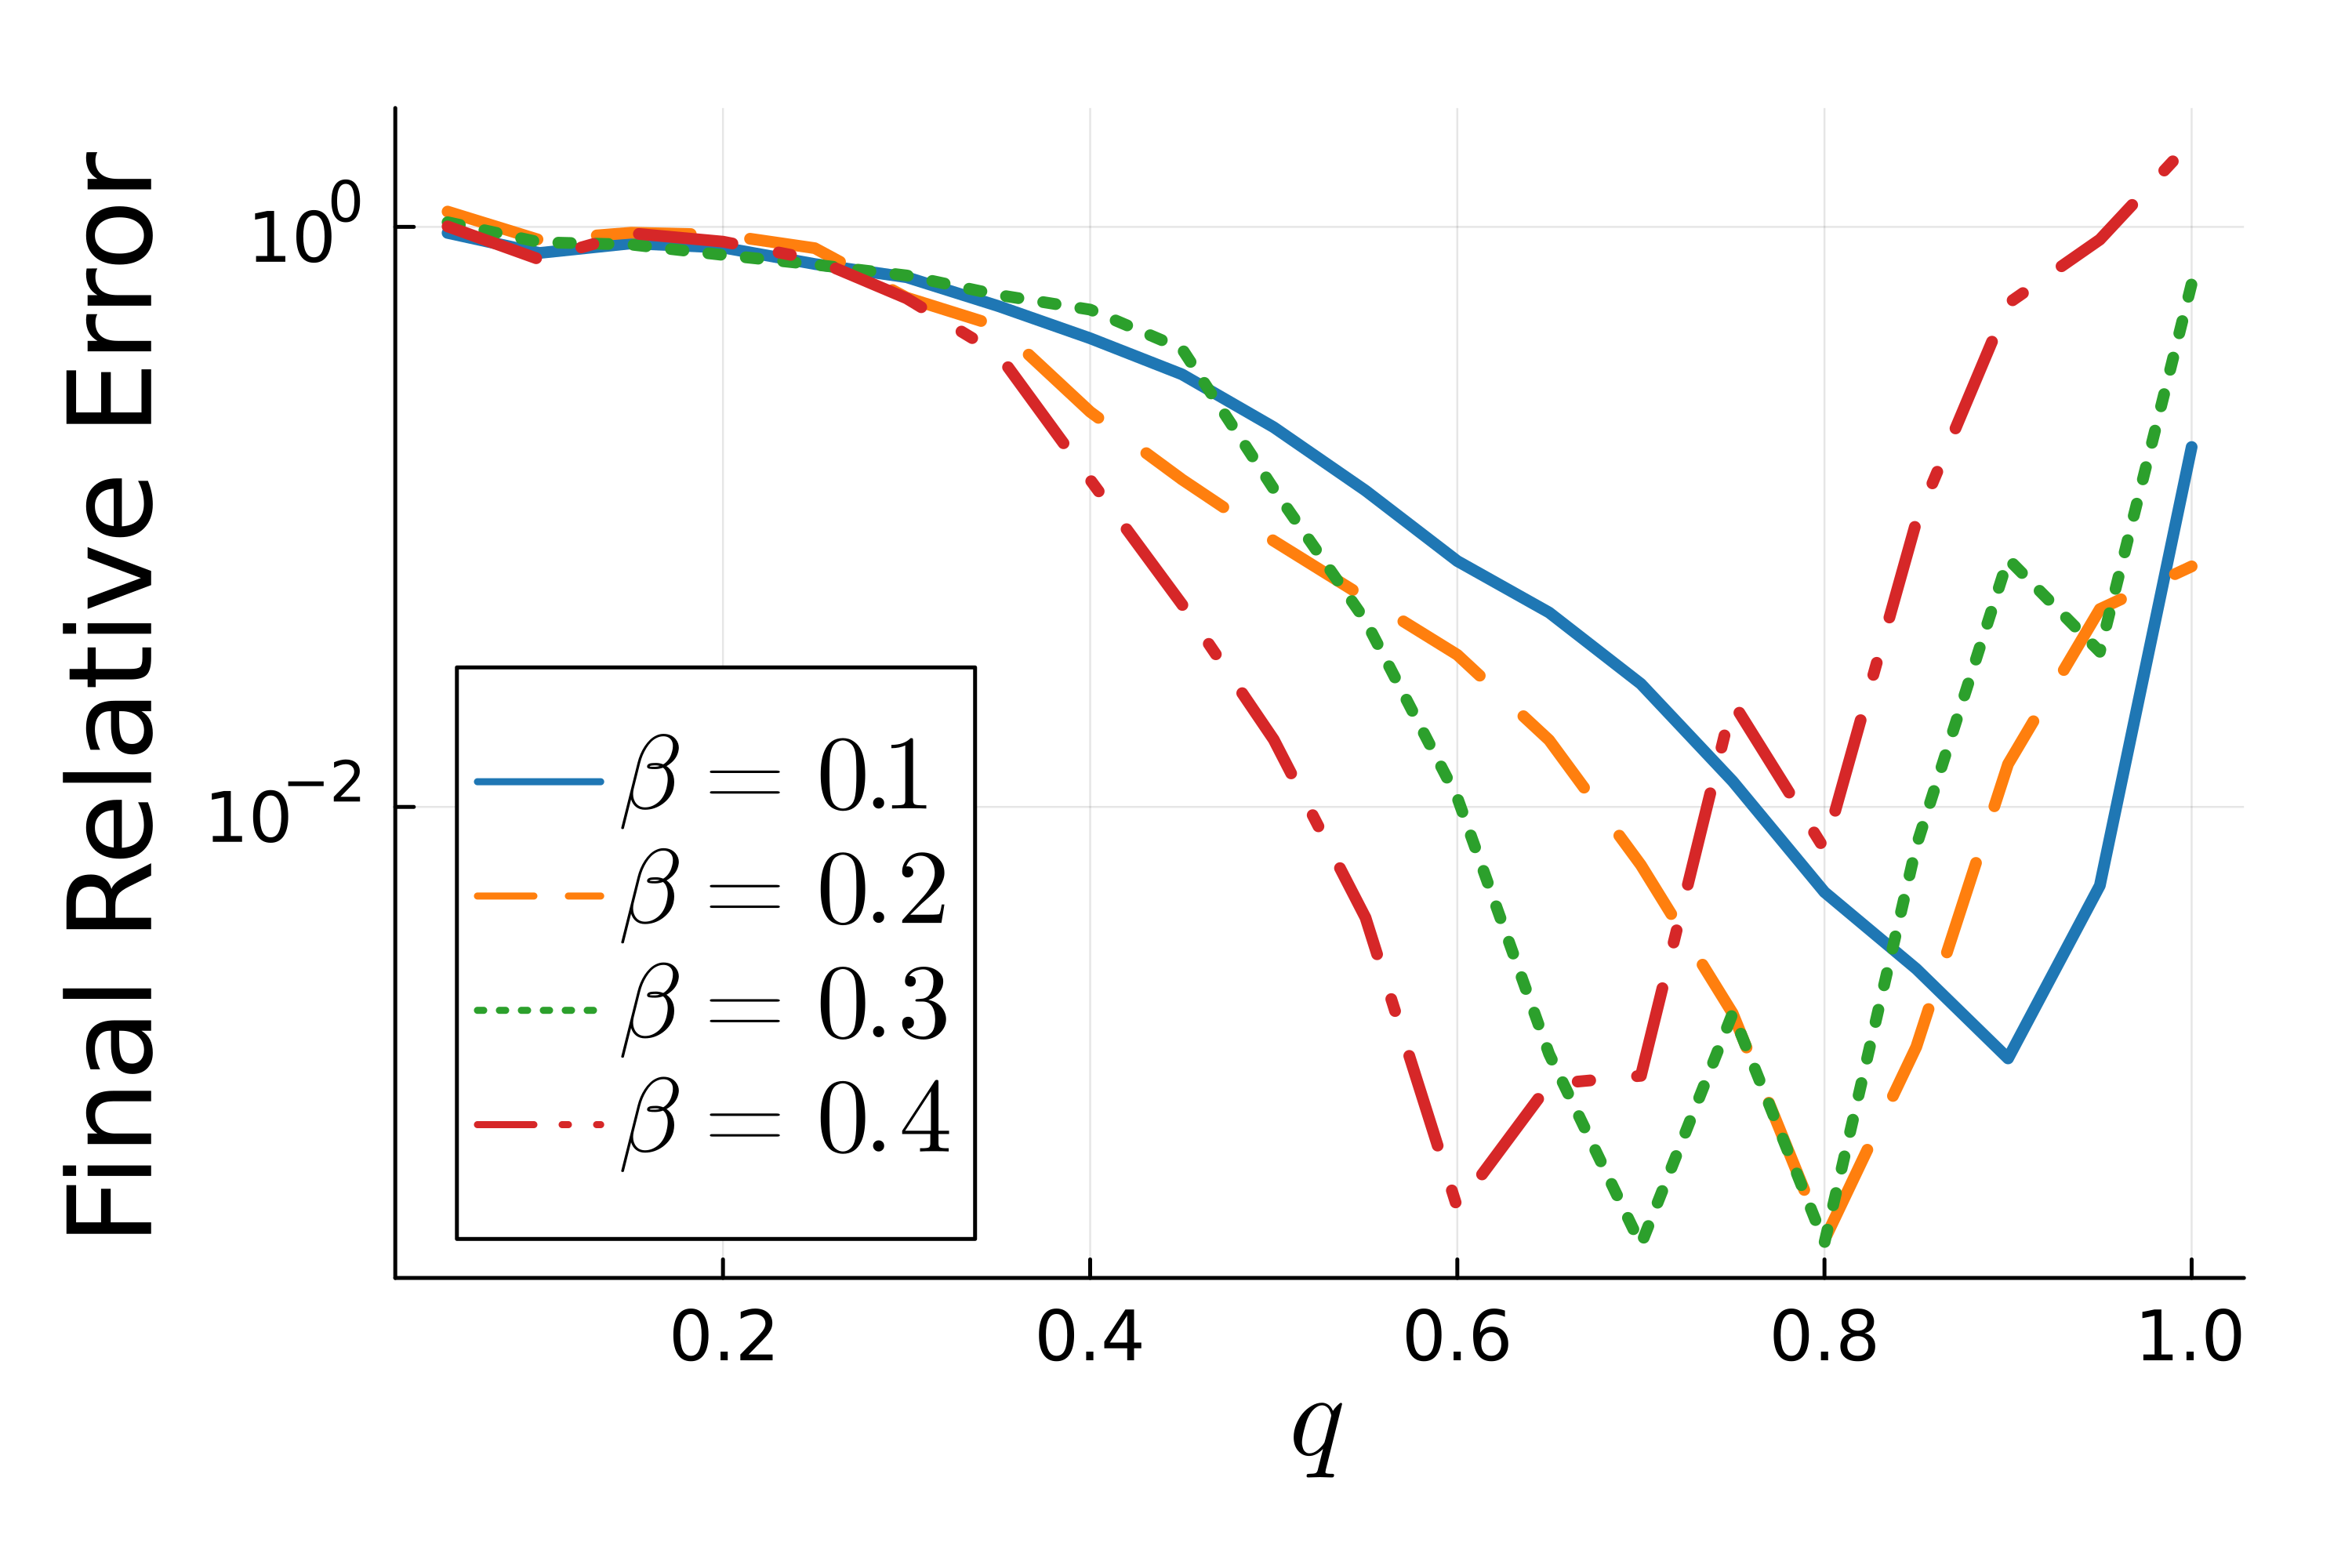

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_error_vs_q.png"

In [26]:
colors = palette(:tab10)
linestyles = [:solid, :dash, :dot, :dashdot]

p = plot(
    xlabel=L"q",
    ylabel="Final Relative Error",
    lw=3,
    dpi=500,
    margin=5mm,
    legend=:bottomleft,
)

for (j, beta) in enumerate(betas)
    plot!(
        qs,
        final_errs[j, :],
        color=colors[j],
        linestyle=linestyles[j],
        label=nothing,
        yscale=:log10,
        lw=3
    )
    # Burner plots (only for legend, thin lines)
    plot!([NaN], [NaN], 
        color=colors[j],
        linestyle=linestyles[j],
        label=L"\beta = %$(beta)",
        lw=0.8
    )
end

display(p)
savefig("figs/polyregression_error_vs_q.png")

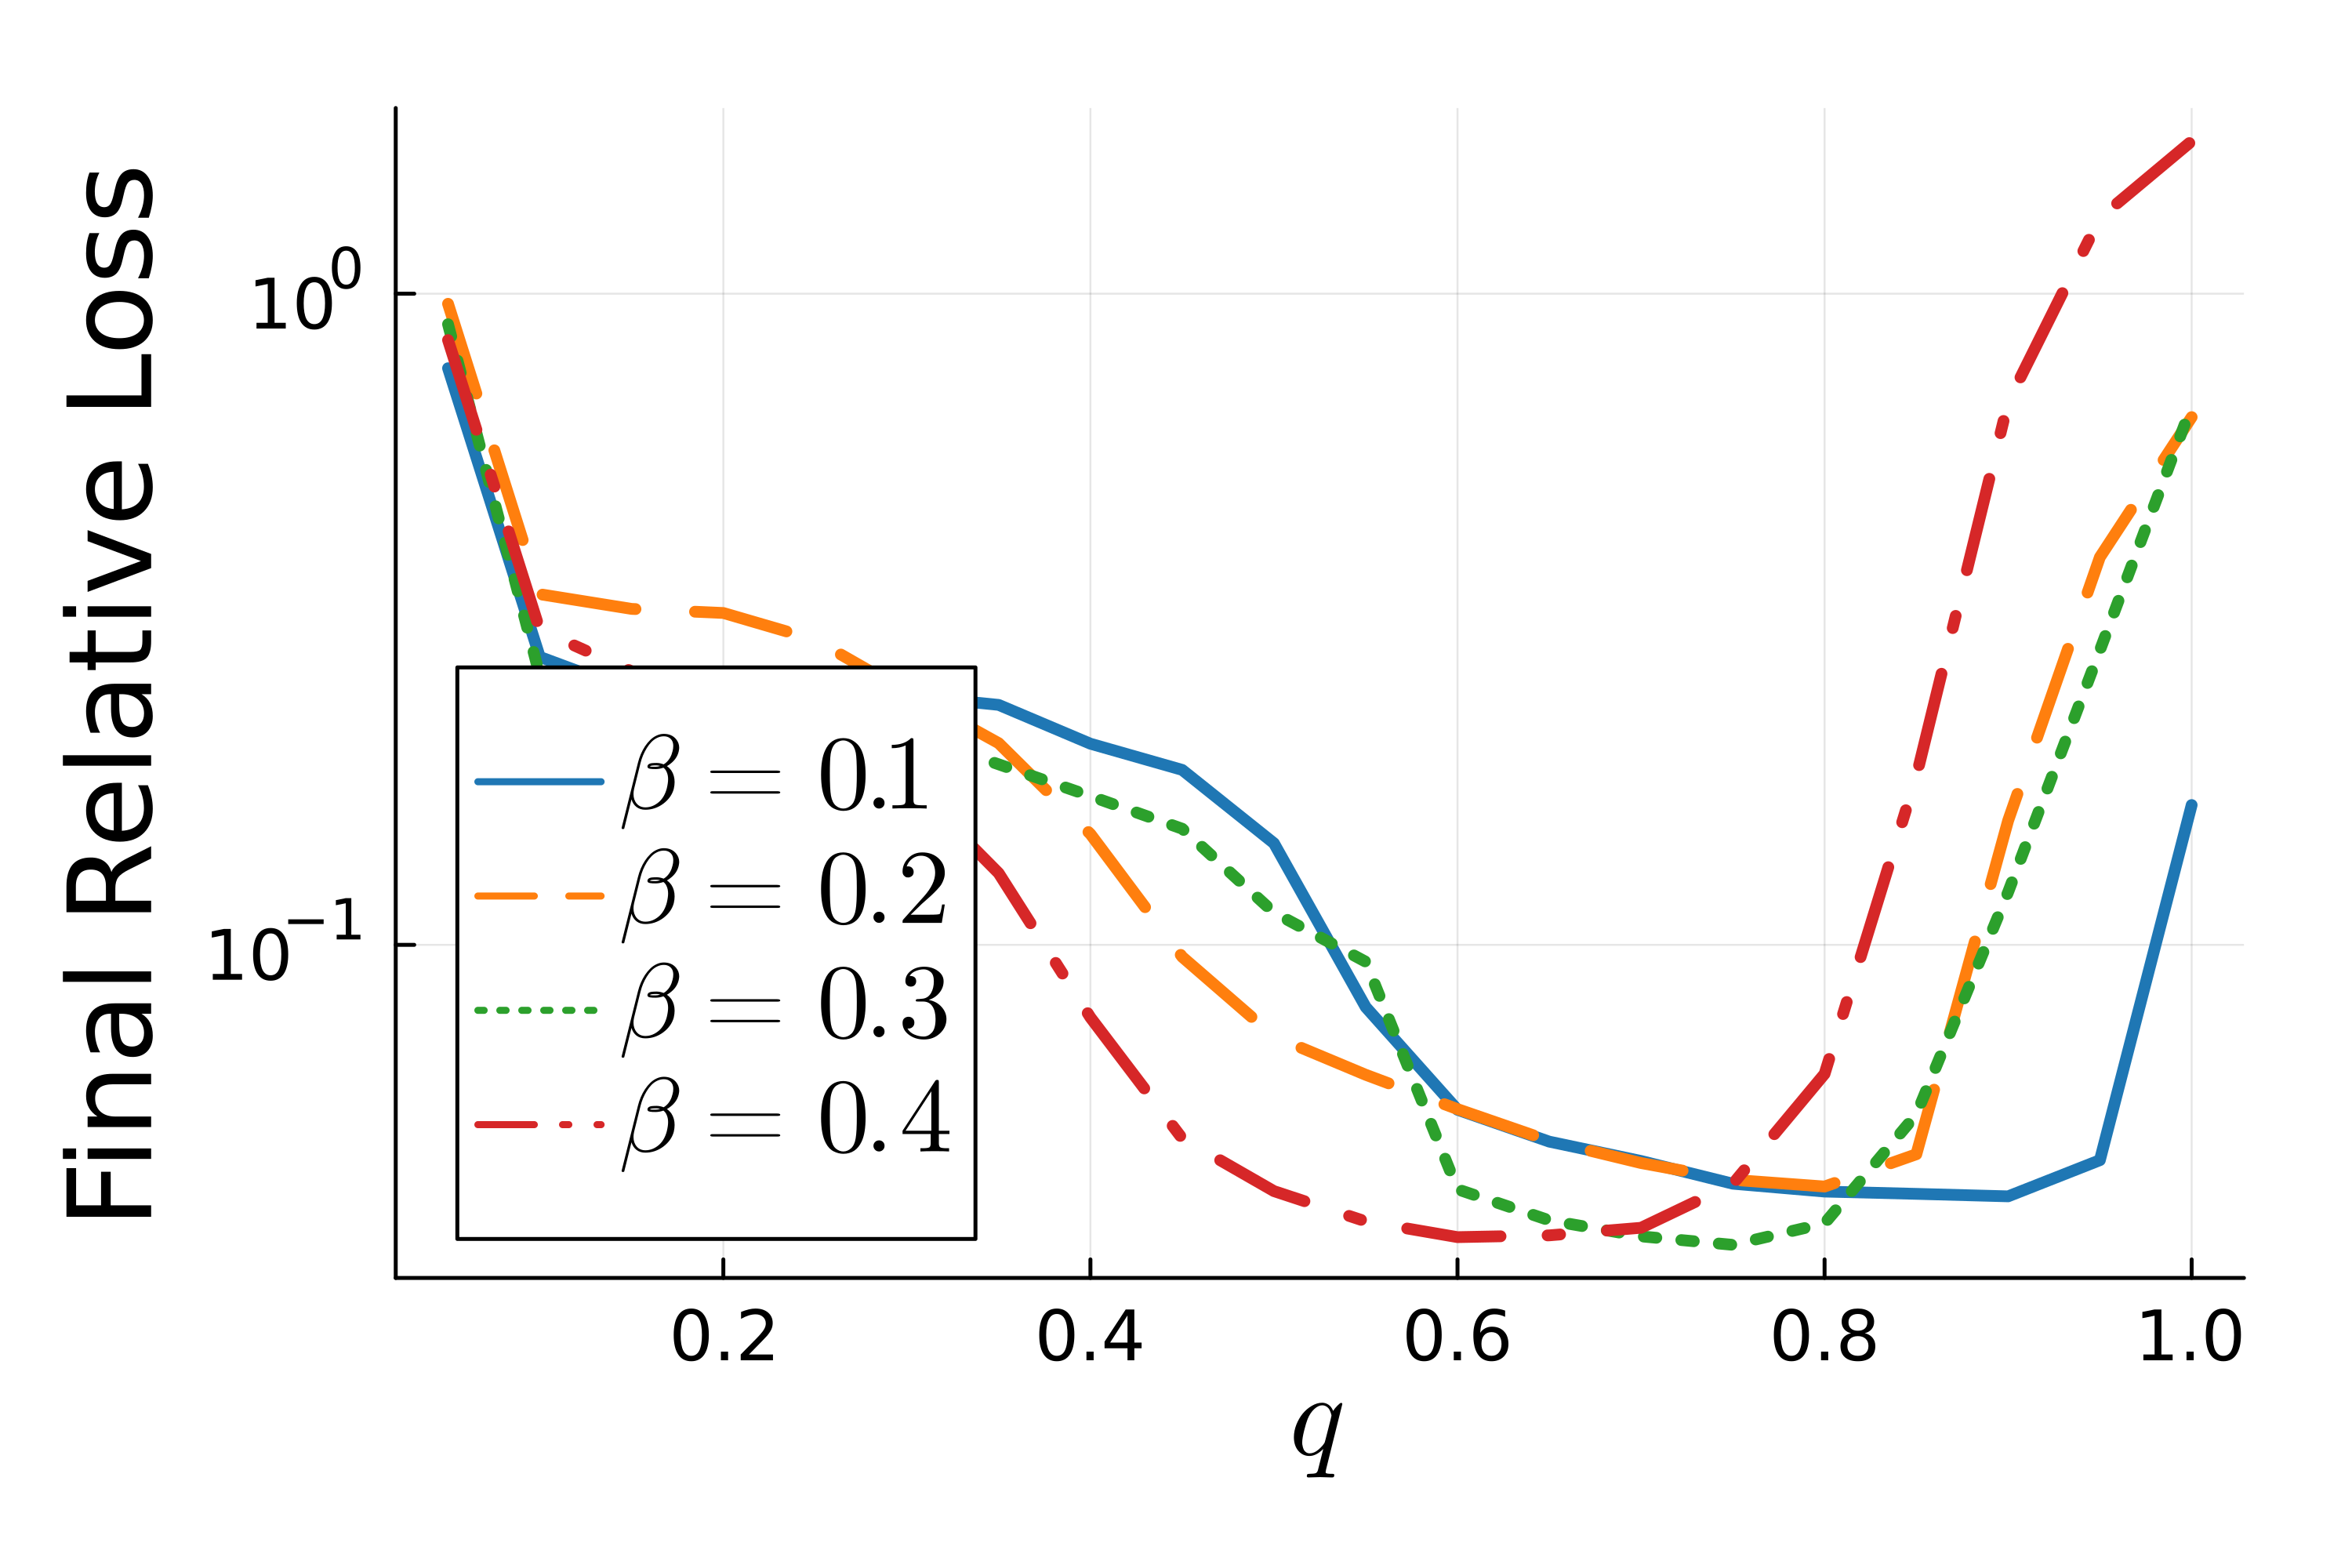

"/Users/jamiehaddock/Dropbox/RESEARCH/COLLAB CorruptSGD/code/JuliaCode/figs/polyregression_loss_vs_q.png"

In [27]:
p = plot(
    xlabel=L"q",
    ylabel="Final Relative Loss",
    lw=3,
    dpi=500,
    margin=5mm,
    legend=:bottomleft,
)

for (j, beta) in enumerate(betas)
    plot!(
        qs,
        final_losses[j, :],
        color=colors[j],
        linestyle=linestyles[j],
        label=nothing,
        yscale=:log10,
        lw=3
    )
    # Burner plots (only for legend, thin lines)
    plot!([NaN], [NaN], 
        color=colors[j],
        linestyle=linestyles[j],
        label=L"\beta = %$(beta)",
        lw=0.8
    )
end

display(p)
savefig("figs/polyregression_loss_vs_q.png")